# ADNI Dataset

In [1]:
import os
import re
import torch
import operator
import numpy as np
import pandas as pd
import nibabel as nib
import statsmodels.api as sm
import imageio.v2 as imageio
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import xml.etree.ElementTree as ET


from typing import Union, Any, Tuple, Dict
from scipy.spatial.distance import jensenshannon
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

/home/stud/kgutjahr/miniconda3/envs/stil/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
BASE_PATH = "/data/local/kgutjahr/datasets/ADNI"
PROCESSED_PATH = os.path.join(BASE_PATH, "dataset_files")

In [3]:
img = nib.load("/data/local/kgutjahr/datasets/ADNI/ADNI1_Annual_2_Yr_3T/ADNI1_Annual_2_Yr_3T/ADNI/023_S_0030/MPR__GradWarp__B1_Correction__N3__Scaled/2007-11-13_12_58_18.0/I87493/ADNI_023_S_0030_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20080115173619365_S42714_I87493.nii")
data = img.get_fdata()

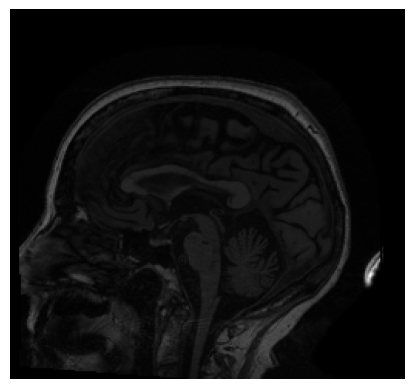

(240, 256, 160)

In [4]:
plt.imshow(data[:, :, data.shape[2] // 2], cmap="gray")
plt.axis("off")
plt.show()
display(data.shape)

In [5]:
def get_counts(df: pd.DataFrame, feature: str, split_value: float = -1.0) -> pd.DataFrame:
    
    if split_value != -1:
        below_or_equal = df[df[feature] <= split_value].shape[0]
        above = df[df[feature] > split_value].shape[0]
        total = below_or_equal + above
        summary = pd.DataFrame({
            'Count': [below_or_equal, above],
            'Percentage': [round(below_or_equal / total * 100, 3), round(above / total * 100, 3)]
        }, index=[f'≤ {split_value}', f'> {split_value}'])
        return summary
    
    counts = df[feature].value_counts()
    percentages = df[feature].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Count': counts,
        'Percentage': percentages.round(3)
    })
    return summary

In [6]:
def visualize_tsne(dfs, labels, continuous_columns: list[str], categorical_columns: list[str], n_components=2, random_state=42, sample_frac=0.2):
    # Add dataset labels
    print(continuous_columns)
    print(categorical_columns)
    
    new_dfs = []
    for df, label in zip(dfs, labels):
        df = df.loc[:, categorical_columns+continuous_columns]
        df['__source'] = label
        new_dfs.append(df)
        #display(df)

    # Combine DataFrames
    combined = pd.concat(new_dfs).reset_index(drop=True)

    # Optional sampling
    sampled = combined.sample(frac=sample_frac, random_state=random_state).reset_index(drop=True)
    source_labels = sampled['__source']
    sampled = sampled.drop(columns='__source')

    # One-hot encode categorical columns if provided
    if categorical_columns:
        sampled = pd.get_dummies(sampled, columns=categorical_columns)

    # Run t-SNE
    tsne = TSNE(n_components=n_components, random_state=random_state)
    reduced = tsne.fit_transform(sampled)

    # Compute label sizes in sampled data
    label_counts = source_labels.value_counts()
    sorted_labels = label_counts.sort_values().index.tolist()  # smallest to largest

    # Plot t-SNE results
    plt.figure(figsize=(8, 6))
    for label in sorted_labels:
        idx = source_labels == label
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=label, alpha=0.6)
    plt.title('t-SNE Projection')
    plt.legend()
    plt.xticks([])
    plt.yticks([])
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [7]:
def plot_histogram_comparison(train: pd.Series, val: pd.Series, test: pd.Series, feature: str,bins: int = 50) -> None:
    plt.figure(figsize=(10, 6))

    # Plot histograms on the same axis
    plt.hist(train.dropna(), bins=bins//3,label='Train', color='blue', edgecolor='black', weights=np.ones(len(train)) * 100 / len(train))
    plt.hist(val.dropna(),   bins=bins//3,label='Val',   color='red', edgecolor='black', weights=np.ones(len(val)) * 100 / len(val))
    plt.hist(test.dropna(),  bins=bins, label='Test',  color='green', edgecolor='black', weights=np.ones(len(test)) * 100 / len(test))

    # Customize
    plt.title(f'{feature} Distribution', fontsize=18)
    plt.xlabel(feature, fontsize=16)
    plt.ylabel('% of split', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_distributions(df: pd.DataFrame, feature: str, highlight_dict: dict[int, str] = {}, misc_limit: int = 0, bins: int = 50) -> None:
    counts_df = get_counts(df=df, feature=feature)
    
    plt.figure(figsize=(10, 6))

    if len(counts_df) > 50:
        counts_df.sort_index(inplace=True)
        counts, bins_edges = np.histogram(counts_df.index, bins=bins)

        # Convert counts to percentage
        percentages = counts / counts.sum() * 100

        # Compute bin centers for correct alignment
        bin_centers = (bins_edges[:-1] + bins_edges[1:]) / 2
        bar_widths = np.diff(bins_edges)

        # Plot the histogram manually using bar
        plt.bar(bin_centers, percentages, width=bar_widths, align='center',
                alpha=0.5, label='Train', color='blue', edgecolor='black')
        plt.ylabel('Percentage %')

    else:
        # Step 1: Summarize entries below threshold
        low_count = counts_df[counts_df["Count"] < misc_limit]
        high_count = counts_df[counts_df["Count"] >= misc_limit]

        # Step 2: Add "Miscellaneous" as a new row
        misc_total = low_count["Count"].sum()
        misc_perc = low_count["Percentage"].sum()
        if misc_total > 0:
            misc_row = pd.DataFrame({"Count": [misc_total], "Percentage": [misc_perc]}, index=["Miscellaneous"])
            df_plot = pd.concat([high_count, misc_row])
        else:
            df_plot = high_count.copy()

        ## Step 3: Sort (optional)
        #df_plot = df_plot.sort_values(by="Count", ascending=False)

        # Step 4: Plot
        ax = df_plot["Count"].plot(kind='bar', color='skyblue', edgecolor='black', width=1)
        plt.ylabel('Frequency', fontsize=16)

        # Step 5: Highlight selected bars using the new index
        for i, label in enumerate(df_plot.index):
            if i in highlight_dict:
                ax.patches[i].set_facecolor(highlight_dict[i])
                
            if len(plt.gca().get_xticks()) > 50:
                plt.locator_params(axis='x', nbins=25)

    # Customize the plot
    plt.title(f'{feature} distribution', fontsize=18)
    plt.xlabel(feature, fontsize=16)
    plt.tight_layout()
    plt.xticks(rotation=45, fontsize=14)
    plt.yticks(fontsize=14)

    # Show the plot
    plt.show()

In [9]:
def calc_normalized_dists(count_df: pd.DataFrame) -> pd.DataFrame:
    return count_df['Count'] / count_df['Count'].sum()

In [10]:
def plot_compare_distribution(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, feature: str, feature_name: str) -> None:
    train_counts = get_counts(df=train_df, feature=feature)
    val_counts = get_counts(df=val_df, feature=feature)
    test_counts = get_counts(df=test_df, feature=feature)

    train_norm = calc_normalized_dists(count_df=train_counts)
    val_norm = calc_normalized_dists(count_df=val_counts)
    test_norm = calc_normalized_dists(count_df=test_counts)   
    
    train_pct = train_norm / train_norm.sum() * 100
    val_pct = val_norm / val_norm.sum() * 100
    test_pct = test_norm / test_norm.sum() * 100
    
    display(train_pct)
    display(val_pct)
    display(test_pct)
    
    plt.figure(figsize=(12, 6))
    plt.plot(feature, train_pct, label='Train', marker='o')
    plt.plot(feature, val_pct, label='Validation', marker='s')
    plt.plot(feature, test_pct, label='Test', marker='^')
    plt.xticks(rotation=45)
    
    plt.ylabel('% of split')
    plt.title(f'{feature_name} Distribution Comparison')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [11]:
def denormalize_column(df: pd.DataFrame, column: str, means: pd.Series, stds: pd.Series) -> pd.Series:
    mean = means[column]
    std = stds[column]
    col = df[column] * std + mean
    return col.reset_index(drop=True)

In [12]:
def plot_histogram_comparison(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, feature: str, feature_name: str, bins: int = 50) -> None:
    plt.figure(figsize=(10, 6))

    # Plot histograms on the same axis
    plt.hist(train_df[feature].dropna(), bins=bins, label='Train', color='blue', edgecolor='black', weights=np.ones(len(train_df)) * 100 / len(train_df))
    plt.hist(val_df[feature].dropna(),   bins=bins, label='Val',   color='red', edgecolor='black', weights=np.ones(len(val_df)) * 100 / len(val_df))
    plt.hist(test_df[feature].dropna(),  bins=bins, label='Test',  color='green', edgecolor='black', weights=np.ones(len(test_df)) * 100 / len(test_df))

    # Customize
    #plt.title(f'{feature} Distribution', fontsize=18)
    plt.xlabel(feature_name, fontsize=16)
    plt.ylabel('% of split', fontsize=16)
    plt.legend(fontsize=14)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.tight_layout()
    plt.show()

In [13]:
def plot_scatter(df: pd.DataFrame, feature: str, label: str, mapping: dict) -> None:
    label_map = mapping[label]
    corr = df[feature].corr(df[label], method="spearman")
    plt.scatter(df[feature], df[label])
    plt.title(f'{feature} vs {label} (r = {corr:.2f})')
    plt.xlabel(feature)
    plt.yticks(ticks=list(label_map.values()), labels=list(label_map.keys()))
    plt.grid(True)
    plt.show()

In [14]:
def calc_JS(first_dist: pd.DataFrame, second_dist: pd.DataFrame) -> float:
    first_dist.index = pd.to_numeric(first_dist.index, errors='coerce')
    first_dist = first_dist[first_dist.index.notna()]
    second_dist.index = pd.to_numeric(second_dist.index, errors='coerce')
    second_dist = second_dist[second_dist.index.notna()]
    
    first_sorted = first_dist.sort_index()
    second_sorted = second_dist.sort_index()
    js = jensenshannon(first_sorted, second_sorted)
    return float(js)

In [15]:
def plot_grouped_bar_from_raw(dfs, labels, feature, plot_value="Percentage", category_order=None, figsize=(8,5), alpha=0.6, title=None):
    """
    Plot a grouped bar chart from raw DataFrames for a categorical feature.

    Parameters:
    - dfs: list of raw pandas DataFrames.
    - labels: list of dataset labels for legend.
    - feature: str, column name in dfs to aggregate (categorical feature).
    - plot_value: str, "Count" or "Percentage".
    - category_order: list, order of categories on x-axis.
    - figsize: tuple, figure size.
    - alpha: float, bar transparency.
    - title: str, plot title.
    """
    
    labeled_dfs = []
    for df, label in zip(dfs, labels):
        counts_df = df[feature].value_counts().sort_index()
        percentages = 100 * counts_df / counts_df.sum()
        temp_df = pd.DataFrame({"Group": counts_df.index, "Count": counts_df.values, "Percentage": percentages.values})
        temp_df["Source"] = label
        labeled_dfs.append(temp_df)
    
    df_all = pd.concat(labeled_dfs)
    
    # Set category order
    if category_order is not None:
        df_all["Group"] = pd.Categorical(df_all["Group"], categories=category_order, ordered=True)
    
    groups = df_all["Group"].cat.categories if category_order is not None else df_all["Group"].unique()
    n_groups = len(groups)
    n_datasets = len(labels)
    
    bar_width = 0.8 / n_datasets  # width of each bar
    x = np.arange(n_groups)       # positions for groups
    
    plt.figure(figsize=figsize)
    
    # Plot bars side by side
    for i, label in enumerate(labels):
        data = df_all[df_all["Source"] == label].set_index("Group").reindex(groups)
        plt.bar(x + i*bar_width, data[plot_value], width=bar_width, alpha=alpha, label=label)
    
    plt.xticks(x + bar_width*(n_datasets-1)/2, groups)
    plt.xlabel(feature)
    plt.ylabel(plot_value)
    plt.title(title if title else f"{plot_value} of {feature} Across Datasets")
    plt.legend(title="Dataset")
    plt.show()

## Load Data

In [16]:
def get_leaf_directories(root_dir):
    leaf_dirs = []
    root_dir = root_dir if isinstance(root_dir, list) else [root_dir]
    for root in root_dir:
        for dirpath, dirnames, filenames in os.walk(root):
            if not dirnames:  # no subdirectories → it's a leaf
                leaf_dirs.append(dirpath)
    return leaf_dirs

def get_files(dir):
    return [os.path.join(dir, f) for f in os.listdir(dir) if os.path.isfile(os.path.join(dir, f))]

In [17]:
def get_subject_dicts(collections: list[str], base_path: str):
    subject_dict_list = []
    for c in collections:
        TAB_PATH = os.path.join(base_path, f"{c}/{c}_metadata")
        IM_PATH = os.path.join(base_path, f"{c}/{c}/ADNI")

        subjects = [i for i in os.listdir(TAB_PATH) if os.path.isdir(os.path.join(TAB_PATH, i))]
        print(len(subjects))

        subject_metadata_dir = {k: [] for k in subjects}
        for key in subject_metadata_dir.keys():
            for i in os.listdir(TAB_PATH):
                path = os.path.join(TAB_PATH, i)
                if not os.path.isfile(path):
                    continue
                if key in path:
                    subject_metadata_dir[key].append(path)

        subject_image_dir = {k: "" for k in subjects}
        for key in subject_image_dir.keys():
            for i in os.listdir(IM_PATH):
                path = os.path.join(IM_PATH, i)
                if not os.path.isdir(path):
                    continue
                if key in path:
                    subject_image_dir[key] = path

        subject_image_ids_dir = {k: get_leaf_directories(v) for k, v in subject_image_dir.items()}
        subject_image_ids = {k: [os.path.basename(path) for path in v] for k, v in subject_image_ids_dir.items()}

        for sub in subjects:
            new_dict: dict[str, Any] = {"subject_id": sub}
            new_dict["data"] = []
            for ids in subject_image_ids[sub]:
                id_metapath = [s for s in subject_metadata_dir[sub] if ids in s][0]
                id_image = [im for im in get_leaf_directories(subject_image_ids_dir[sub]) if ids in im][0]
                id_image = get_files(id_image)[0]
                new_dict["data"].append({"tab_path": id_metapath, "image_path": id_image, "id": ids})
            subject_dict_list.append(new_dict)

    return subject_dict_list

In [18]:
import re
import xml.etree.ElementTree as ET
import pandas as pd

def parse_ida_xml_to_dataframe(xml_path: str) -> pd.DataFrame:
    """
    Parse an IDA XML file (like ADNI structure) into a flat pandas DataFrame.
    - Handles mixed namespaces automatically.
    - Produces one row per subject/visit/study/series combination.
    - Assessment scores, subjectInfo entries, and image protocol terms become columns.
    """

    # --- Load XML and strip namespaces ---
    with open(xml_path, "r", encoding="utf-8") as f:
        xml_text = f.read()

    xml_text = re.sub(r'\sxmlns(:\w+)?="[^"]+"', '', xml_text)
    xml_text = re.sub(r'xsi:[a-zA-Z]+="[^"]+"', '', xml_text)

    root = ET.fromstring(xml_text)

    records = []

    for project in root.findall(".//project"):
        project_id = project.findtext("projectIdentifier")
        project_desc = project.findtext("projectDescription")
        site_key = project.findtext("siteKey")

        for subject in project.findall(".//subject"):
            subj_id = subject.findtext("subjectIdentifier")
            group = subject.findtext("researchGroup")
            sex = subject.findtext("subjectSex")

            # --- Gather <subjectInfo> key-value pairs ---
            subject_info = {}
            for info in subject.findall(".//subjectInfo"):
                key = info.get("item")
                val = info.text
                if key:
                    subject_info[key] = val

            # --- Study info ---
            for study in subject.findall(".//study"):
                study_id = study.findtext("studyIdentifier")
                subj_age = study.findtext("subjectAge")
                weight = study.findtext("weightKg")
                postmortem = study.findtext("postMortem")

                for series in study.findall(".//series"):
                    series_id = series.findtext("seriesIdentifier")
                    modality = series.findtext("modality")
                    date_acq = series.findtext("dateAcquired")

                    # --- Extract protocol-level metadata (slice thickness, TE, TR, etc.) ---
                    protocol_info = {}
                    for proto in series.findall(".//protocol"):
                        term = proto.get("term")
                        val = proto.text
                        if term:
                            protocol_info[term] = val

                    base_record = {
                        "projectIdentifier": project_id,
                        "projectDescription": project_desc,
                        "siteKey": site_key,
                        "subjectIdentifier": subj_id,
                        "researchGroup": group,
                        "subjectSex": sex,
                        "studyIdentifier": study_id,
                        "subjectAge": subj_age,
                        "weightKg": weight,
                        "postMortem": postmortem,
                        "seriesIdentifier": series_id,
                        "modality": modality,
                        "dateAcquired": date_acq,
                    }

                    # Add subjectInfo and protocol details
                    base_record.update(subject_info)
                    base_record.update(protocol_info)

                    # --- Visits and Assessments ---
                    for visit in subject.findall(".//visit"):
                        visit_id = visit.findtext("visitIdentifier")
                        record = base_record.copy()
                        record["visitIdentifier"] = visit_id

                        # Collect assessments into columns
                        for assessment in visit.findall(".//assessment"):
                            for component in assessment.findall(".//component"):
                                score_elem = component.find(".//assessmentScore")
                                if score_elem is not None:
                                    score_attr = score_elem.get("attribute")
                                    score_value = score_elem.text
                                    if score_attr:
                                        record[score_attr] = score_value

                        records.append(record)

    df = pd.DataFrame(records)
    df = df.drop_duplicates()

    return df

In [19]:
collections = ["ADNI1_Annual_2_Yr_3T", "ADNI1_Complete_1Yr_3T", "ADNI1_Complete_1Yr_1.5T", "ADNI1_Complete_2Yr_1.5T", "ADNI1_Complete_2Yr_3T", "ADNI1_Complete_3Yr_1.5T", "ADNI1_Complete_3Yr_3T"]

subject_dict_list = get_subject_dicts(collections=collections, base_path=BASE_PATH)
len(subject_dict_list)

89
119
639
419
36
382
42


1726

In [20]:
def get_tabular_data(dict_list):
    df_full = pd.DataFrame()
    for d in dict_list:
        for point in d["data"]:
            path = point["tab_path"]
            df = parse_ida_xml_to_dataframe(path)
            df["im_path"] = point["image_path"]
            df["dataIdentifier"] = df["subjectIdentifier"] + "_" + df["studyIdentifier"]
            if df_full.empty:
                df_full = df
            else:
                df_full = pd.concat([df_full, df])
    return df_full.reset_index(drop=True)
                
tab_data = get_tabular_data(dict_list=subject_dict_list)
tab_data

,projectIdentifier,projectDescription,siteKey,subjectIdentifier,researchGroup,subjectSex,studyIdentifier,subjectAge,weightKg,postMortem,...,Mfg Model,Field Strength,visitIdentifier,NPISCORE,FAQTOTAL,im_path,dataIdentifier,MMSCORE,GDTOTAL,CDGLOBAL
0,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,4893,66.8466,58.06,F,...,Achieva,3.0,ADNI Baseline,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,130_S_0449_4893,NaN,NaN,NaN
1,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,11625,67.8767,56.7,F,...,Achieva,3.0,ADNI1/GO Month 12,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,130_S_0449_11625,27.0,2.0,0.5
2,ADNI,Alzheimer's Disease Neuroimaging Initiative,130,130_S_0449,MCI,F,17355,68.8356,60.78,F,...,Achieva,3.0,ADNI1/GO Month 24,3.0,11.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,130_S_0449_17355,29.0,1.0,0.5
3,ADNI,Alzheimer's Disease Neuroimaging Initiative,116,116_S_0382,CN,F,4239,75.6986,63.73,F,...,Trio,2.89362,ADNI Baseline,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,116_S_0382_4239,NaN,NaN,NaN
4,ADNI,Alzheimer's Disease Neuroimaging Initiative,116,116_S_0382,CN,F,9326,76.6986,63.5,F,...,Trio,3.0,ADNI1/GO Month 12,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,116_S_0382_9326,29.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4598,ADNI,Alzheimer's Disease Neuroimaging Initiative,032,032_S_1169,CN,F,24831,75.3315,74.84,F,...,TrioTim,3.0,ADNI1/GO Month 36,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,032_S_1169_24831,30.0,3.0,0.5
4599,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_0331,MCI,F,20973,67.7151,61.6,F,...,Trio,3.0,ADNI1/GO Month 36,3.0,5.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,023_S_0331_20973,23.0,8.0,0.5
4600,ADNI,Alzheimer's Disease Neuroimaging Initiative,023,023_S_0331,MCI,F,13134,66.211,64.41,F,...,Trio,3.0,ADNI1/GO Month 18,3.0,3.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,023_S_0331_13134,25.0,NaN,0.5
4601,ADNI,Alzheimer's Disease Neuroimaging Initiative,136,136_S_0429,MCI,M,22163,65.8849,79.38,F,...,Achieva,3.0,ADNI1/GO Month 36,5.0,4.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,136_S_0429_22163,26.0,4.0,0.5


In [21]:
(tab_data.isna().sum() / len(tab_data) * 100).sort_values(ascending=False)

GDTOTAL               35.411688
FAQTOTAL              18.770367
NPISCORE              18.487943
Acquisition Type      14.142950
MMSCORE                6.495764
CDGLOBAL               6.408864
Pixel Spacing X        0.000000
Flip Angle             0.000000
Acquisition Plane      0.000000
Matrix X               0.000000
Matrix Y               0.000000
Matrix Z               0.000000
Mfg Model              0.000000
Pixel Spacing Y        0.000000
Manufacturer           0.000000
TI                     0.000000
Field Strength         0.000000
visitIdentifier        0.000000
im_path                0.000000
dataIdentifier         0.000000
Coil                   0.000000
projectIdentifier      0.000000
projectDescription     0.000000
postMortem             0.000000
siteKey                0.000000
subjectIdentifier      0.000000
researchGroup          0.000000
subjectSex             0.000000
studyIdentifier        0.000000
subjectAge             0.000000
weightKg               0.000000
seriesId

In [22]:
tab_data["dataIdentifier"].nunique()
c_tab_data = tab_data.drop_duplicates(subset='dataIdentifier', keep='first').reset_index(drop=True)
#tab_data["subjectIdentifier"].nunique()
display(c_tab_data.columns)
display(len(c_tab_data))
display(c_tab_data["subjectIdentifier"].value_counts().mean())
display(c_tab_data["subjectIdentifier"].value_counts().std())
display(c_tab_data["subjectIdentifier"].nunique())
display(c_tab_data["dateAcquired"].value_counts())

Index(['projectIdentifier', 'projectDescription', 'siteKey',
       'subjectIdentifier', 'researchGroup', 'subjectSex', 'studyIdentifier',
       'subjectAge', 'weightKg', 'postMortem', 'seriesIdentifier', 'modality',
       'dateAcquired', 'APOE A1', 'APOE A2', 'Acquisition Type', 'Weighting',
       'Pulse Sequence', 'Slice Thickness', 'TE', 'TR', 'TI', 'Coil',
       'Flip Angle', 'Acquisition Plane', 'Matrix X', 'Matrix Y', 'Matrix Z',
       'Pixel Spacing X', 'Pixel Spacing Y', 'Manufacturer', 'Mfg Model',
       'Field Strength', 'visitIdentifier', 'NPISCORE', 'FAQTOTAL', 'im_path',
       'dataIdentifier', 'MMSCORE', 'GDTOTAL', 'CDGLOBAL'],
      dtype='object')

3412

5.289922480620155

2.0584564621103296

645

2007-02-09    15
2007-08-20    13
2007-06-06    12
2007-11-13    11
2006-11-28    11
              ..
2006-08-29     1
2008-12-04     1
2007-08-18     1
2008-09-21     1
2009-07-01     1
Name: dateAcquired, Length: 1034, dtype: int64

In [23]:
relevant_cols = ["dataIdentifier", "subjectIdentifier", "researchGroup", "subjectSex", "subjectAge", "weightKg", "NPISCORE", "FAQTOTAL", "im_path", "MMSCORE", "CDGLOBAL", "APOE A1", "APOE A2", "Slice Thickness", "Field Strength", "TE", "TR", "TI", "Manufacturer"]

df_no_nan = tab_data.dropna(subset=relevant_cols)

relevant_df = df_no_nan[relevant_cols].reset_index(drop=True)
relevant_df = relevant_df.drop_duplicates(subset='dataIdentifier', keep='first').reset_index(drop=True)

# possible labels
# CN: cognitively normal
# MCI: mild cognitive impairment
# AD: Alzheimer's disease
#relevant_df["researchGroup"].unique()
print(relevant_df.shape)
relevant_cols

(2620, 19)


['dataIdentifier',
 'subjectIdentifier',
 'researchGroup',
 'subjectSex',
 'subjectAge',
 'weightKg',
 'NPISCORE',
 'FAQTOTAL',
 'im_path',
 'MMSCORE',
 'CDGLOBAL',
 'APOE A1',
 'APOE A2',
 'Slice Thickness',
 'Field Strength',
 'TE',
 'TR',
 'TI',
 'Manufacturer']

In [24]:
def fix_dtypes(df: pd.DataFrame, dtypes: dict[str, str]) -> pd.DataFrame:
    for col, dtype in dtypes.items():
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame, skipping.")
            continue
        
        try:
            # Special case for datetime
            if "datetime" in dtype:
                df[col] = pd.to_datetime(df[col], errors="coerce")
            else:
                df[col] = df[col].astype(dtype)
        except Exception as e:
            print(f"Could not convert column '{col}' to {dtype}: {e}")
    
    return df

In [25]:
relevant_df

,dataIdentifier,subjectIdentifier,researchGroup,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,im_path,MMSCORE,CDGLOBAL,APOE A1,APOE A2,Slice Thickness,Field Strength,TE,TR,TI,Manufacturer
0,130_S_0449_11625,130_S_0449,MCI,F,67.8767,56.7,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,27.0,0.5,4,4,1.2,3.0,3.2544,6.8482,0.0,Philips Medical Systems
1,130_S_0449_17355,130_S_0449,MCI,F,68.8356,60.78,3.0,11.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.5,4,4,1.2,3.0,3.2544,6.8482,0.0,Philips Medical Systems
2,116_S_0382_9326,116_S_0382,CN,F,76.6986,63.5,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.0,3,3,1.2,3.0,2.94,2300.0,900.0,SIEMENS
3,116_S_0382_16134,116_S_0382,CN,F,77.6575,63.5,2.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.0,3,3,1.2,3.0,2.94,2300.0,900.0,SIEMENS
4,023_S_1190_19390,023_S_1190,CN,F,78.6658,60.51,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,30.0,0.0,3,3,1.2,3.0,2.94,2300.0,900.0,SIEMENS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615,023_S_0926_23726,023_S_0926,CN,F,74.2986,75.21,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,30.0,0.0,3,3,1.2,3.0,2.94,2300.0,900.0,SIEMENS
2616,018_S_0450_22011,018_S_0450,MCI,M,71.7014,52.16,2.0,9.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,26.0,1.0,3,4,1.2,3.0,3.1329,6.7657,0.0,Philips Medical Systems
2617,032_S_1169_24831,032_S_1169,CN,F,75.3315,74.84,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,30.0,0.5,3,3,1.2,3.0,2.91,2300.0,900.0,SIEMENS
2618,023_S_0331_20973,023_S_0331,MCI,F,67.7151,61.6,3.0,5.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,23.0,0.5,4,4,1.2,3.0,2.94,2300.0,900.0,SIEMENS


In [26]:
relevant_df["Manufacturer"].value_counts()

GE MEDICAL SYSTEMS         1217
SIEMENS                    1041
Philips Medical Systems     362
Name: Manufacturer, dtype: int64

In [27]:
correct_dtypes = {"dataIdentifier": "string", "subjectIdentifier": "string", "researchGroup": "string", "subjectSex": "string",
                  "subjectAge": "float64", "weightKg": "float64", "NPISCORE": "float64", "FAQTOTAL": "float64", "im_path": "string",
                  "MMSCORE": "float64", "CDGLOBAL": "float64", "APOE A1": "int64", "APOE A2": "int64",
                  "Slice Thickness": "float64", "Field Strength": "float64", "TE": "float64", "TR": "float64", "TI": "float64", "Manufacturer": "string"}
relevant_df = fix_dtypes(df=relevant_df, dtypes=correct_dtypes)

In [28]:
relevant_df.dtypes

dataIdentifier        string
subjectIdentifier     string
researchGroup         string
subjectSex            string
subjectAge           float64
weightKg             float64
NPISCORE             float64
FAQTOTAL             float64
im_path               string
MMSCORE              float64
CDGLOBAL             float64
APOE A1                int64
APOE A2                int64
Slice Thickness      float64
Field Strength       float64
TE                   float64
TR                   float64
TI                   float64
Manufacturer          string
dtype: object

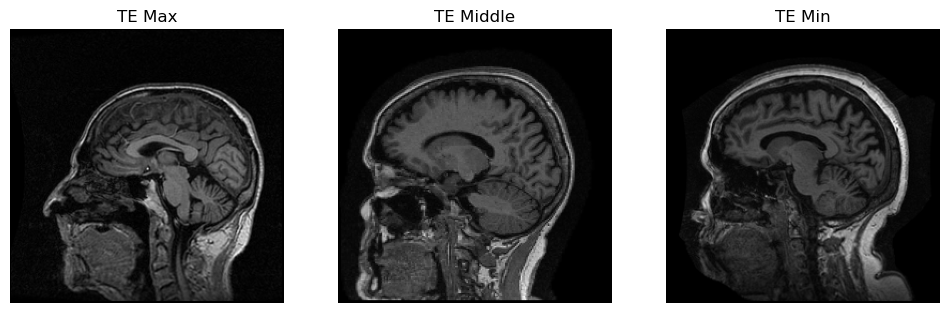

In [29]:
img_col = "TE"

img_te_max = nib.load(relevant_df.loc[relevant_df[img_col].idxmax()]["im_path"])
img_te_min = nib.load(relevant_df.loc[relevant_df[img_col].idxmin()]["im_path"])
middle_row = relevant_df.loc[(relevant_df[img_col] - (relevant_df[img_col].max() + relevant_df[img_col].min()) / 2).abs().idxmin()]["im_path"]
img_te_middle = nib.load(middle_row)

data_te_max = img_te_max.get_fdata()
data_te_min = img_te_min.get_fdata()
data_te_middle = img_te_middle.get_fdata()

slice_index = data_te_max.shape[2] // 2
slice_max = data_te_max[:, :, slice_index]
slice_min = data_te_min[:, :, slice_index]
slice_middle = data_te_middle[:, :, slice_index]

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(12, 6))  # 1 row, 2 columns

# Left image
axes[0].imshow(slice_max, cmap="gray")
axes[0].axis("off")
axes[0].set_title(f"{img_col} Max")

# Middle image
axes[1].imshow(slice_middle, cmap="gray")
axes[1].axis("off")
axes[1].set_title(f"{img_col} Middle")

# Right image
axes[2].imshow(slice_min, cmap="gray")
axes[2].axis("off")
axes[2].set_title(f"{img_col} Min")

plt.show()

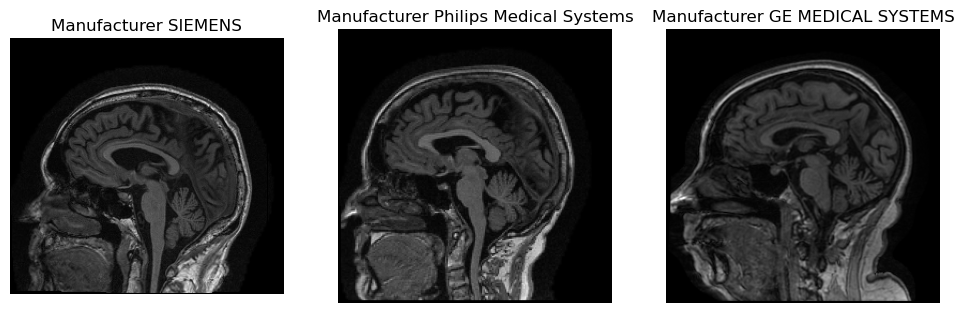

In [30]:
img_col = "Manufacturer"

img_te_max = nib.load(relevant_df[relevant_df[img_col] == "SIEMENS"]["im_path"].reset_index(drop=True)[50])
img_te_min = nib.load(relevant_df[relevant_df[img_col] == "GE MEDICAL SYSTEMS"]["im_path"].reset_index(drop=True)[50])
img_te_middle = nib.load(relevant_df[relevant_df[img_col] == "Philips Medical Systems"]["im_path"].reset_index(drop=True)[50])

data_te_max = img_te_max.get_fdata()
data_te_min = img_te_min.get_fdata()

slice_index = data_te_max.shape[2] // 2
slice_max = data_te_max[:, :, slice_index]
slice_min = data_te_min[:, :, slice_index]
slice_middle = data_te_middle[:, :, slice_index]

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(12, 6))  # 1 row, 2 columns

# Left image
axes[0].imshow(slice_max, cmap="gray")
axes[0].axis("off")
axes[0].set_title(f"{img_col} SIEMENS")

# Middle image
axes[1].imshow(slice_middle, cmap="gray")
axes[1].axis("off")
axes[1].set_title(f"{img_col} Philips Medical Systems")

# Right image
axes[2].imshow(slice_min, cmap="gray")
axes[2].axis("off")
axes[2].set_title(f"{img_col} GE MEDICAL SYSTEMS")

plt.show()

In [31]:
def get_slice(path):
    img = nib.load(path)
    data = img.get_fdata()
    slice = data[:, :, data.shape[2] // 2]
    slice_norm = (slice - np.min(slice)) / (np.max(slice) - np.min(slice))
    slice_uint8 = (slice_norm * 255).astype(np.uint8)
    return slice_uint8

def get_png_path(path: str, dir: str):
    return os.path.join(dir, os.path.basename(path)[:-3] + "png")
    
def save_image(series: pd.Series, dir: str):
    for row in series:
        png_path = get_png_path(path=row, dir=dir)
        if not os.path.exists(png_path):
            img = get_slice(path=row)
            # Save as PNG
            imageio.imwrite(png_path, img)

save_image(series=relevant_df["im_path"], dir=PROCESSED_PATH)

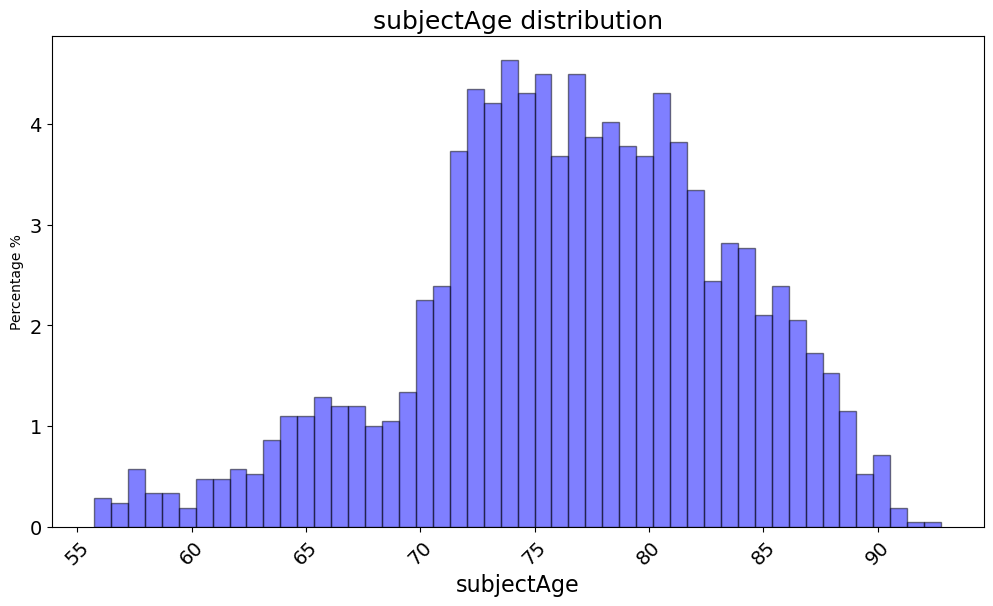

In [32]:
plot_distributions(df=relevant_df, feature="subjectAge")

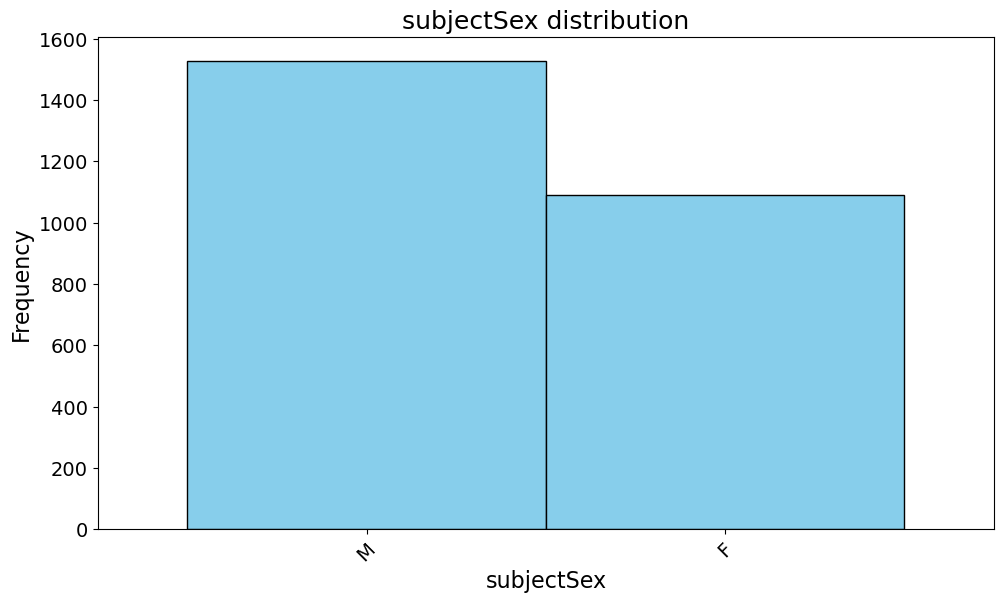

In [33]:
plot_distributions(df=relevant_df, feature="subjectSex")

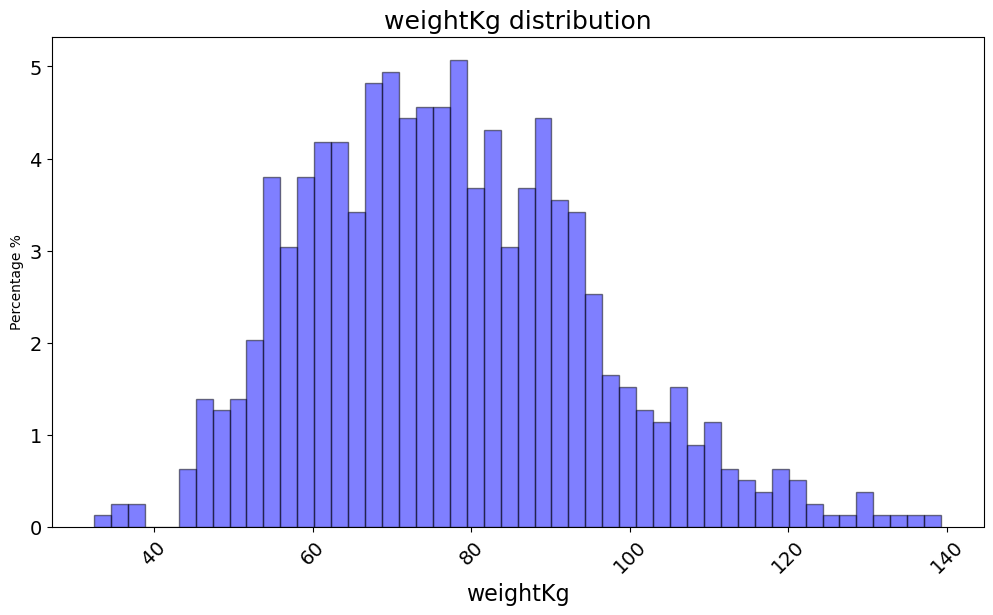

In [34]:
relevant_df = relevant_df[relevant_df["weightKg"] > 0.0]
plot_distributions(df=relevant_df, feature="weightKg")

In [35]:
relevant_df.shape

(2618, 19)

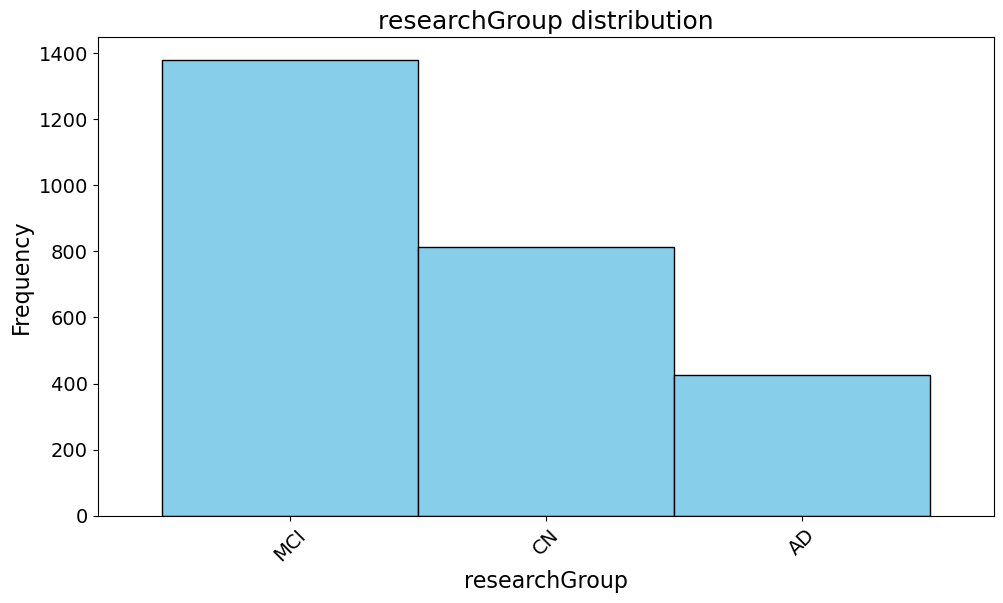

In [36]:
plot_distributions(df=relevant_df, feature="researchGroup")

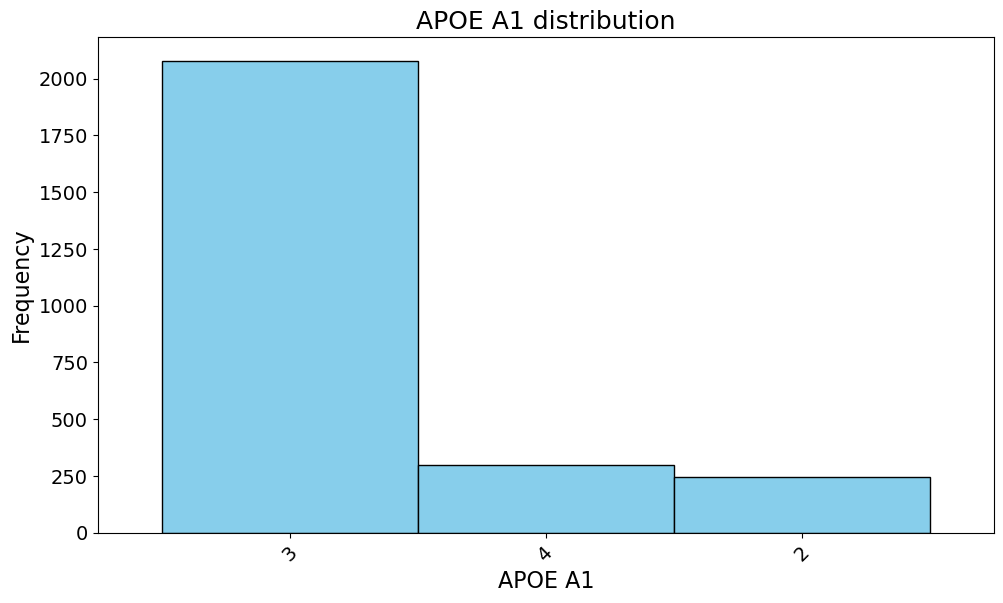

In [37]:
plot_distributions(df=relevant_df, feature="APOE A1")

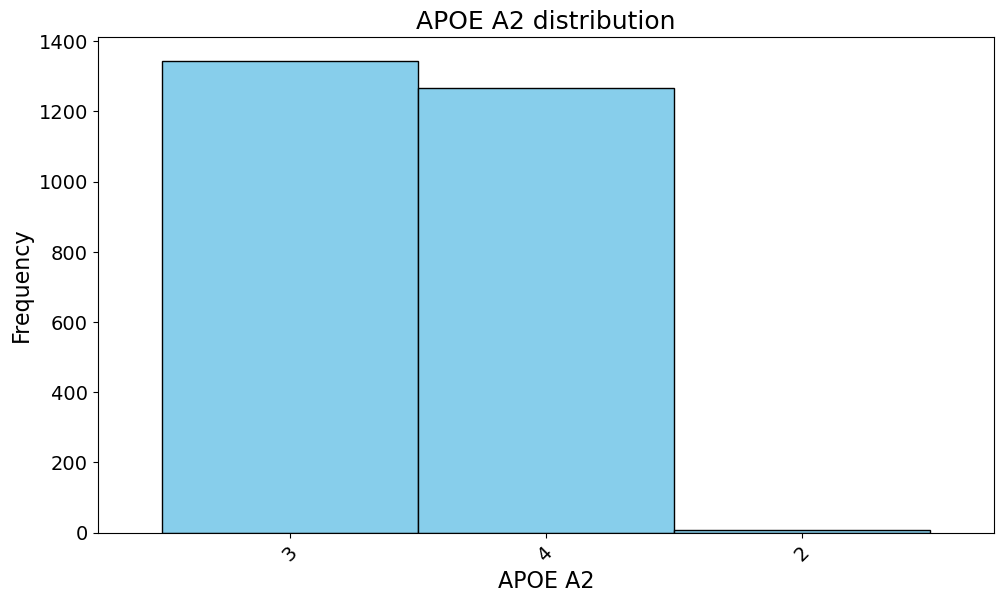

In [38]:
plot_distributions(df=relevant_df, feature="APOE A2")

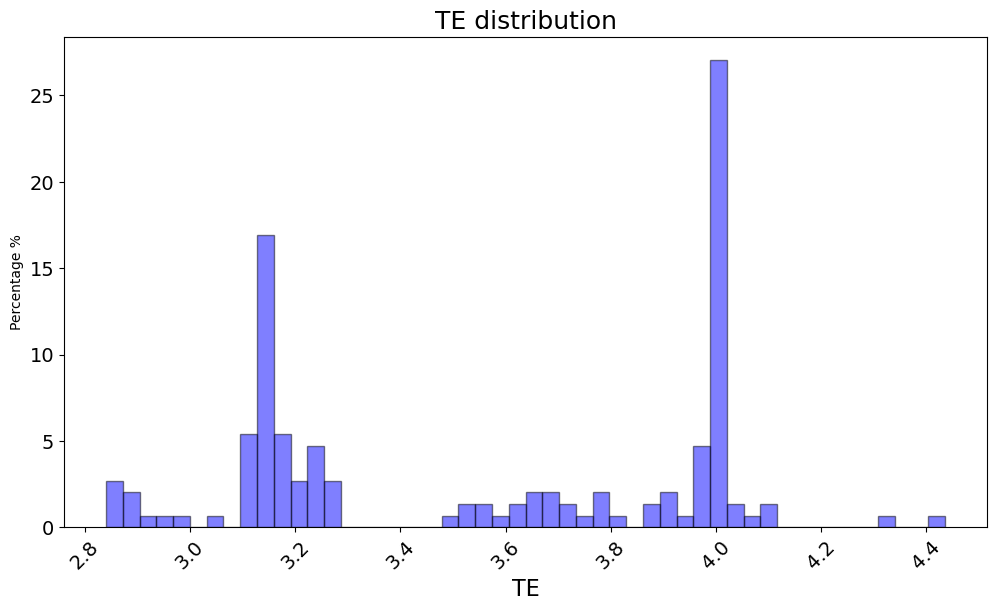

In [39]:
plot_distributions(df=relevant_df, feature="TE")

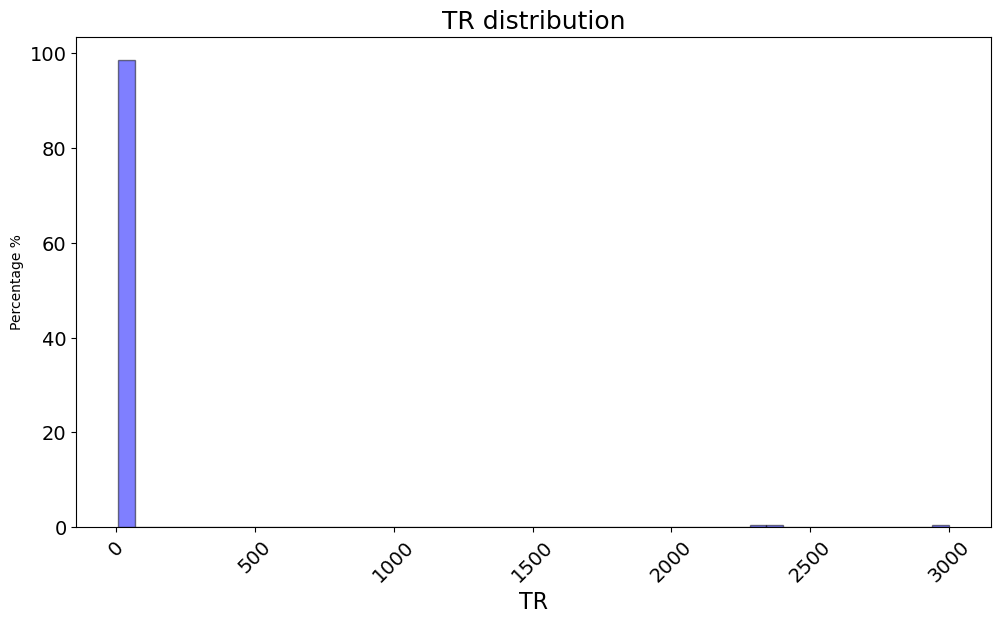

In [40]:
plot_distributions(df=relevant_df, feature="TR")

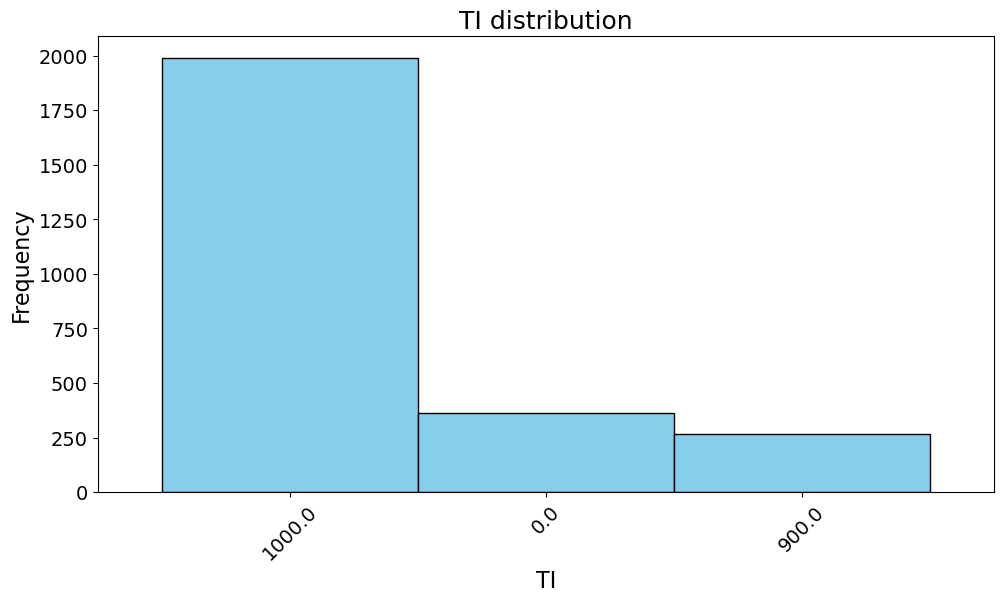

In [41]:
plot_distributions(df=relevant_df, feature="TI")

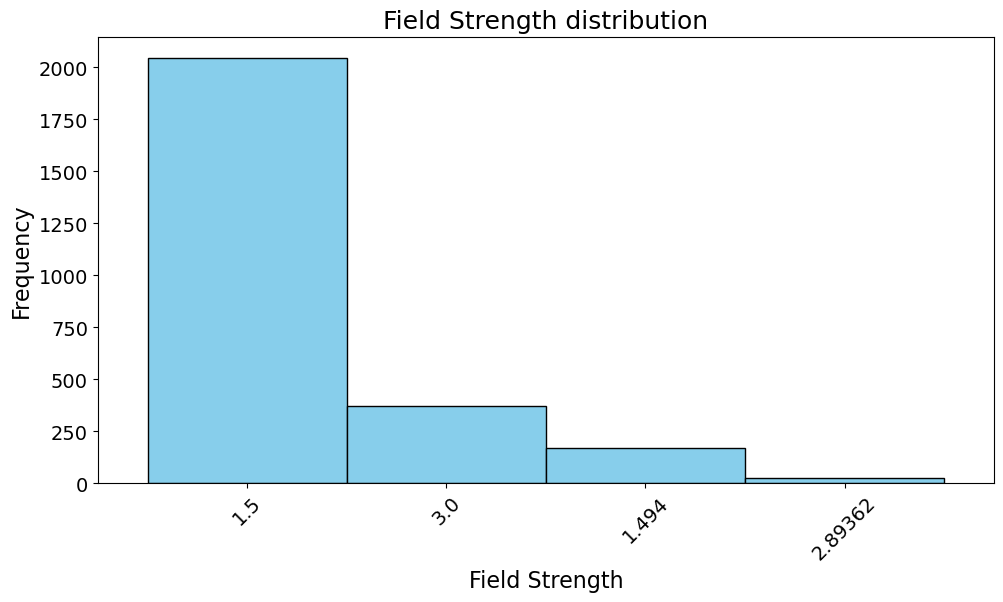

In [42]:
plot_distributions(df=relevant_df, feature="Field Strength")

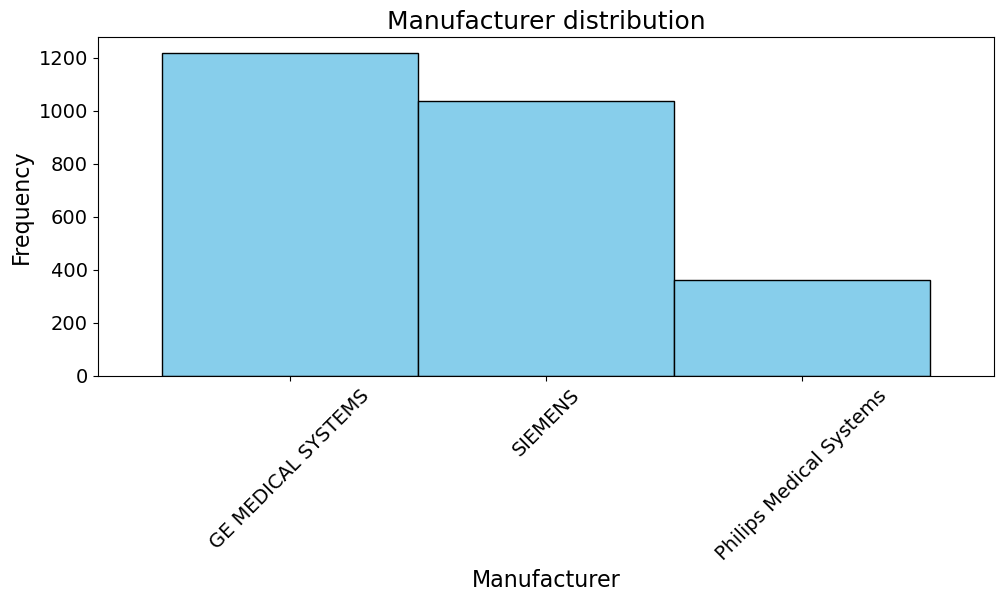

In [43]:
plot_distributions(df=relevant_df, feature="Manufacturer")

## Split Data

In [44]:
def create_shift_mask(df: pd.DataFrame, filters: list[Dict[str, str]], filter_cond: str, con_columns: list[str], cat_columns: list[str]) -> pd.Series:
    first_bool = True if filter_cond == "and" else False
    
    ops = {
        "==": operator.eq,
        "!=": operator.ne,
        ">": operator.gt,
        ">=": operator.ge,
        "<": operator.lt,
        "<=": operator.le,
    }

    mask = pd.Series(first_bool, index=df.index)
    for f in filters:
        for col, val in f.items():
            if col in con_columns:
                if isinstance(val, tuple):
                    op_str, threshold = val
                    mask &= ops[op_str](df[col], threshold)
                else:
                    mask &= df[col] == val
            elif col in cat_columns:
                if isinstance(val, tuple):
                    op_str, threshold = val
                    mask |= ops[op_str](df[col], threshold)
                else:
                    mask |= df[col] == val
                    
    return mask

In [45]:
def data_split(df: pd.DataFrame, nclasses: int, split: Union[float, int]) -> np.ndarray:
    # 1. Keep only top-n classes
    top_classes = df['researchGroup'].value_counts().nlargest(nclasses).index
    df = df[df['researchGroup'].isin(top_classes)].copy()

    # 2. Aggregate by subject: one row per subject
    # Each subject gets a single representative label (mode of researchGroup)
    subject_labels = (
        df.groupby('subjectIdentifier')['researchGroup']
        .agg(lambda x: x.mode()[0])
        .reset_index()
    )

    # 3. Convert split to test_size (since StratifiedShuffleSplit expects test_size)
    if isinstance(split, int):
        train_size = split / len(df)
    else:
        train_size = split
    test_size = 1 - train_size

    # 4. Perform stratified split at subject level
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=2023)
    train_idx, test_idx = next(sss.split(subject_labels, subject_labels['researchGroup']))

    train_subjects = subject_labels.iloc[train_idx]['subjectIdentifier']
    test_subjects = subject_labels.iloc[test_idx]['subjectIdentifier']

    # 5. Map back to full dataset
    train_df = df[df['subjectIdentifier'].isin(train_subjects)]
    test_df = df[df['subjectIdentifier'].isin(test_subjects)]

    # 6. Sanity checks
    assert not set(train_df['subjectIdentifier']) & set(test_df['subjectIdentifier']), \
        "Overlap detected: a subject appears in both splits!"

    return train_df["dataIdentifier"].values

In [46]:
def create_cutted_split(df: pd.DataFrame, size: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    nclasses = df["researchGroup"].nunique()
    df_ids = data_split(df=df, nclasses=nclasses, split=size)
    first_df = df.loc[df['dataIdentifier'].isin(df_ids)]
    second_df = df.loc[~df['dataIdentifier'].isin(df_ids)]
    return first_df.reset_index(drop=True), second_df.reset_index(drop=True)

In [47]:
def create_dataset(tab_data: pd.DataFrame, train_ratio: float, val_ratio: float, test_ratio: float):
    train_val, test = create_cutted_split(df=tab_data, size=1 - test_ratio)
    val_size_relative = val_ratio / (train_ratio + val_ratio)
    train, val = create_cutted_split(df=train_val, size=1 - val_size_relative)
    return train, val, test

In [48]:
def categorize(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, categorical_columns: list[str]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, Dict[str, dict]]:
    # Deep copies to ensure no slice/view issues
    train_df_copy = train_df.copy(deep=True)
    val_df_copy = val_df.copy(deep=True)
    test_df_copy = test_df.copy(deep=True)
    
    category_mappings = {}

    for col in categorical_columns:
        # Combine all categories
        all_categories = pd.Index(
            pd.concat([
                train_df_copy[col],
                val_df_copy[col],
                test_df_copy[col]
            ]).dropna().unique()
        )
        
        # Store the mapping
        mapping = {category: code for code, category in enumerate(all_categories)}
        category_mappings[col] = mapping

        # Assign categories
        for df in (train_df_copy, val_df_copy, test_df_copy):
            df[col] = pd.Categorical(df[col], categories=all_categories)
            df[col] = df[col].cat.codes

    return train_df_copy, val_df_copy, test_df_copy, category_mappings

In [49]:
def normalize(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, continuous_columns: list[str]) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    # Compute mean and std from training set only
    mean = train_df[continuous_columns].mean()
    std = train_df[continuous_columns].std()
    
    non_constant_columns = std[std != 0].index.tolist()

    # Update mean and std
    mean = mean[non_constant_columns]
    std = std[non_constant_columns]

    # use copies for more sanitary workflow
    train_df_copy = train_df.copy()
    val_df_copy = val_df.copy()
    test_df_copy = test_df.copy()

    # Apply normalization using training stats
    train_df_copy[non_constant_columns] = (train_df_copy[non_constant_columns] - mean) / std
    val_df_copy[non_constant_columns] = (val_df_copy[non_constant_columns] - mean) / std
    test_df_copy[non_constant_columns] = (test_df_copy[non_constant_columns] - mean) / std

    return train_df_copy, val_df_copy, test_df_copy, mean, std

In [50]:
def reorder_df(df: pd.DataFrame, new_order: list[str]) -> pd.DataFrame:
    other_columns = list(set(list(df.columns)) - set(new_order))
    
    new_order = new_order + other_columns
    return df[new_order]

In [51]:
def get_lengths(df_list: list[pd.DataFrame], continuous_columns: list[str], categorical_columns: list[str]) -> Dict[str, int]:
    continuous_length = {i: 1 for i in continuous_columns}
    
    max_list = {i: 0 for i in categorical_columns}
    for df in df_list:
        for col in categorical_columns:
            df_col_max = df[col].max()
            max_list[col] = df_col_max if df_col_max > max_list[col] else max_list[col]
            
    max_list = {k: v+1 for k, v in max_list.items()}
    
    return max_list | continuous_length 

In [52]:
def save_dataset(df: pd.DataFrame, save_directory: str, split: str, keep_cols: list[str], image_dir: str) -> None:
    labels_path = f"labels_{split}.pt"
    labels_path = os.path.join(save_directory, labels_path)
    labels = list(df["researchGroup"].reset_index(drop=True))
    if not os.path.exists(labels_path):
        torch.save(labels, labels_path)
        print(f"Saved labels to {labels_path}")
    
    
    img_path = f"image_paths_{split}.pt"
    img_path = os.path.join(save_directory, img_path)
    imgs = df["im_path"].reset_index(drop=True)
    image_paths = [get_png_path(path=im, dir=image_dir) for im in imgs]
    if not os.path.exists(img_path):
        torch.save(image_paths, img_path)
        print(f"Saved image paths to {img_path}")
    
    adni_features_path = f"adni_features_{split}.csv"
    adni_features_path = os.path.join(save_directory, adni_features_path)
    data_df = df[keep_cols].reset_index(drop=True)
    print(data_df.columns)
    if not os.path.exists(adni_features_path):
        data_df.to_csv(path_or_buf=adni_features_path, index=False, header=False)
        print(f"Saved ADNI Features to {adni_features_path}")

In [53]:
def save_lengths(lengths: Dict[str, int], file_name: str, save_directory: str) -> None:
    # save lengths list
    lengths_list = list(lengths.values())
    lengths_path = os.path.join(save_directory, file_name)
    if not os.path.exists(lengths_path):
        torch.save(lengths_list, lengths_path)
        print(f"Saved lengths to {lengths_path}")

In [54]:
def get_num_of_classes(df_list: list[pd.DataFrame], class_col: str) -> int:
    concat_df = pd.concat(df_list, axis=0)
    return concat_df[class_col].nunique()

In [55]:
def create_shifted_splits(df: pd.DataFrame, split: list[Dict[str, Any]], split_cond: str, ratio: list[int], con_columns: list[str], cat_columns: list[str], mode: int = 0) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    '''
    Creates shifted versions of the given DataFrames.
    
    
    Args:
    -----
        df (pd.DataFrame): the original df
        split (list[Dict[str, str]]): The elements that needs to be filtered
        ratio (list[int]): Expects a list containing three integer numbers:
                                first: train size
                                second: validation size
                                third: test size
        mode (int): The mode, i.e. if the newly generated test df should contain all split elements and train/val contain everything else (mode==0) or vice versa (mode==1) 
    '''
    mask = create_shift_mask(df=df, filters=split, filter_cond=split_cond, con_columns=con_columns, cat_columns=cat_columns)
    
    no_df = df[~mask]
    only_df = df[mask]
    
    test_df = pd.DataFrame()
    train_val_df = pd.DataFrame()
    if mode == 0:
        test_df = only_df
        train_val_df = no_df
    elif mode == 1:
        test_df = no_df
        train_val_df = only_df
    else:
        raise ValueError("mode can only be 0 or 1.")
    
    print(len(only_df))
    print(len(no_df))
    

    desired_test_size = min(ratio[2], test_df.shape[0])
    if desired_test_size != test_df.shape[0]:
        test_df, _ = create_cutted_split(df=test_df, size=desired_test_size)
    
    desired_train_val_size = min(ratio[0] + ratio[1], train_val_df.shape[0])
    if desired_train_val_size != train_val_df.shape[0]:
        train_val_df, _ = create_cutted_split(df=train_val_df, size=desired_train_val_size)
    
    common_ids = [i for i in train_val_df["subjectIdentifier"].unique() if i in test_df["subjectIdentifier"].unique()]

    train_val_df = train_val_df[~train_val_df["subjectIdentifier"].isin(common_ids)].reset_index(drop=True)

    desired_val_size = ratio[1]
    val_ids = data_split(df=train_val_df, nclasses=train_val_df["researchGroup"].nunique(), split=desired_val_size)
    
    val_df = train_val_df.loc[train_val_df['dataIdentifier'].isin(val_ids)]
    train_df = train_val_df.loc[~train_val_df['dataIdentifier'].isin(val_ids)]
    
    print(f"Shape of train df:\t{train_df.shape}")
    print(f"Shape of val df:\t{val_df.shape}")
    print(f"Shape of test df:\t{test_df.shape}")
    total_size = train_df.shape[0] + val_df.shape[0] + test_df.shape[0]
    print(f"Total Size: {total_size}")
    print(f"Ratio -> Train: {round(train_df.shape[0] / total_size, 2)} | Val: {round(val_df.shape[0] / total_size, 2)} | Test: {round(test_df.shape[0] / total_size, 2)}")

    return train_df, val_df, test_df

In [56]:
def save_new_datasets(train: pd.DataFrame, val: pd.DataFrame, test: pd.DataFrame, cat_cols: list[str], con_cols: list[str], save_directory: str, image_directory: str):
    print(f"CONTINUUOUS COls: {con_cols}")
    print(f"CATEGORICAL COls: {cat_cols}")
    train_df, val_df, test_df, cat_mapping = categorize(train_df=train,
                                                        val_df=val,
                                                        test_df=test,
                                                        categorical_columns=cat_cols)

    train_df, val_df, test_df, mean, std = normalize(train_df=train_df,
                                                    val_df=val_df,
                                                    test_df=test_df,
                                                    continuous_columns=con_cols)
    
    print(cat_cols[:-1]+con_cols)
    train_df = reorder_df(df=train_df, new_order=cat_cols[:-1]+con_cols)
    val_df = reorder_df(df=val_df, new_order=cat_cols[:-1]+con_cols)
    test_df = reorder_df(df=test_df, new_order=cat_cols[:-1]+con_cols)
    
    lengths = get_lengths(df_list=[train_df, val_df, test_df], continuous_columns=con_cols, categorical_columns=cat_cols[:-1])
    
    visualize_tsne(dfs=[train_df, val_df, test_df], labels=["Train", "Val", "Test"], continuous_columns=con_cols, categorical_columns=cat_cols, sample_frac=1.0)
    
    save_lengths(lengths=lengths, file_name="tabular_lengths.pt", save_directory=save_directory)
    save_dataset(df=train_df, save_directory=save_directory, split="train", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)
    save_dataset(df=val_df, save_directory=save_directory, split="val", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)
    save_dataset(df=test_df, save_directory=save_directory, split="test", keep_cols=cat_cols[:-1]+con_cols, image_dir=image_directory)

In [57]:
def group_to_categories(df: pd.DataFrame, col_bins: Dict[str, list]) -> pd.DataFrame:
    new_df = df.copy()
    for col, bin in col_bins.items():
        labels = range(0, len(bin)-1)
        new_df[col] = pd.cut(x=new_df[col], bins=bin, labels=labels).astype(int)
        
    return new_df

In [58]:
def cut_datasets(train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, sizes: list[int]) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if len(train_df) > sizes[0]:
        train_df = train_df.sample(n=sizes[0], random_state=42).reset_index(drop=True)
    if len(val_df) > sizes[1]:
        val_df = val_df.sample(n=sizes[1], random_state=42).reset_index(drop=True)
    if len(test_df) > sizes[2]:
        test_df = test_df.sample(n=sizes[2], random_state=42).reset_index(drop=True)

    return train_df, val_df, test_df

In [59]:
def multinomial_logistic_regression(df: pd.DataFrame, cat_col: str, con_col: str, reordering: list, n_points=200):
    df = df.copy()
    df[cat_col] = pd.Categorical(
        df[cat_col],
        categories=reordering,
        ordered=False
    )

    # Add constant term (intercept)
    X = sm.add_constant(df[con_col])
    y = df[cat_col]

    # Fit the multinomial logistic regression
    model = sm.MNLogit(y, X)
    result = model.fit()

    # Display results
    print(result.summary())
    
    x_min, x_max = X[con_col].min(), X[con_col].max()
    x_grid = np.linspace(x_min, x_max, n_points)
    
    # Build a new DataFrame for prediction
    X_pred = X.copy()
    X_pred = X_pred.mean().to_frame().T  # start from mean values
    X_pred = pd.concat([X_pred]*n_points, ignore_index=True)
    X_pred[con_col] = x_grid
    
    # Add constant if model has one
    if 'const' in result.params.columns:
        X_pred = sm.add_constant(X_pred, has_constant='add')
    
    # Get predicted probabilities
    pred_probs = result.predict(X_pred)
    
    # Determine category names
    if reordering is None:
        category_labels = result.model.endog_names
    if isinstance(pred_probs, np.ndarray):
        pred_probs = pd.DataFrame(pred_probs, columns=result.model.endog_names)
    
    # Plot
    plt.figure(figsize=(8, 6))
    for i, col in enumerate(pred_probs.columns):
        plt.plot(x_grid, pred_probs[col], label=col, lw=2)
    
    plt.title(f"Predicted Probabilities Across {con_col}")
    plt.xlabel(con_col)
    plt.ylabel("Predicted Probability")
    plt.legend(title="Category")
    plt.grid(alpha=0.3)
    plt.show()

In [60]:
def plot_multinomial_probs(result, X, var_name, category_labels=None, n_points=200):
    """
    Plot predicted probabilities from a fitted statsmodels MNLogit model
    across a continuous predictor.
    
    Parameters
    ----------
    result : statsmodels.discrete.discrete_model.MNLogitResults
        Fitted multinomial logistic regression result object.
    X : pandas.DataFrame
        Original data used to fit the model.
    var_name : str
        Name of the continuous predictor to plot.
    category_labels : list, optional
        Labels for categories (order should match model). If None, inferred.
    n_points : int
        Number of points to use for the prediction grid.
    """
    
    # Create grid of values for the continuous variable
    x_min, x_max = X[var_name].min(), X[var_name].max()
    x_grid = np.linspace(x_min, x_max, n_points)
    
    # Build a new DataFrame for prediction
    X_pred = X.copy()
    X_pred = X_pred.mean().to_frame().T  # start from mean values
    X_pred = pd.concat([X_pred]*n_points, ignore_index=True)
    X_pred[var_name] = x_grid
    
    # Add constant if model has one
    if 'const' in result.params.columns:
        X_pred = sm.add_constant(X_pred, has_constant='add')
    
    # Get predicted probabilities
    pred_probs = result.predict(X_pred)
    
    # Determine category names
    if category_labels is None:
        category_labels = result.model.endog_names
    if isinstance(pred_probs, np.ndarray):
        pred_probs = pd.DataFrame(pred_probs, columns=result.model.endog_names)
    
    # Plot
    plt.figure(figsize=(8, 6))
    for i, col in enumerate(pred_probs.columns):
        plt.plot(x_grid, pred_probs[col], label=col, lw=2)
    
    plt.title(f"Predicted Probabilities Across {var_name}")
    plt.xlabel(var_name)
    plt.ylabel("Predicted Probability")
    plt.legend(title="Category")
    plt.grid(alpha=0.3)
    plt.show()

In [61]:
#if "GDTOTAL" in relevant_df.columns:
#    relevant_df_c = group_to_categories(df=relevant_df, col_bins={"GDTOTAL": [-1,5,15]})
#else:
relevant_df_c = relevant_df
relevant_df_c

,dataIdentifier,subjectIdentifier,researchGroup,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,im_path,MMSCORE,CDGLOBAL,APOE A1,APOE A2,Slice Thickness,Field Strength,TE,TR,TI,Manufacturer
0,130_S_0449_11625,130_S_0449,MCI,F,67.8767,56.70,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,27.0,0.5,4,4,1.2,3.0,3.2544,6.8482,0.0,Philips Medical Systems
1,130_S_0449_17355,130_S_0449,MCI,F,68.8356,60.78,3.0,11.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.5,4,4,1.2,3.0,3.2544,6.8482,0.0,Philips Medical Systems
2,116_S_0382_9326,116_S_0382,CN,F,76.6986,63.50,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.0,3,3,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS
3,116_S_0382_16134,116_S_0382,CN,F,77.6575,63.50,2.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,29.0,0.0,3,3,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS
4,023_S_1190_19390,023_S_1190,CN,F,78.6658,60.51,1.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,30.0,0.0,3,3,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615,023_S_0926_23726,023_S_0926,CN,F,74.2986,75.21,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,30.0,0.0,3,3,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS
2616,018_S_0450_22011,018_S_0450,MCI,M,71.7014,52.16,2.0,9.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,26.0,1.0,3,4,1.2,3.0,3.1329,6.7657,0.0,Philips Medical Systems
2617,032_S_1169_24831,032_S_1169,CN,F,75.3315,74.84,0.0,0.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,30.0,0.5,3,3,1.2,3.0,2.9100,2300.0000,900.0,SIEMENS
2618,023_S_0331_20973,023_S_0331,MCI,F,67.7151,61.60,3.0,5.0,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,23.0,0.5,4,4,1.2,3.0,2.9400,2300.0000,900.0,SIEMENS


Optimization terminated successfully.
         Current function value: 0.992804
         Iterations 5
                          MNLogit Regression Results                          
Dep. Variable:          researchGroup   No. Observations:                 2618
Model:                        MNLogit   Df Residuals:                     2614
Method:                           MLE   Df Model:                            2
Date:                Mon, 12 Jan 2026   Pseudo R-squ.:                0.003489
Time:                        18:59:25   Log-Likelihood:                -2599.2
converged:                       True   LL-Null:                       -2608.3
Covariance Type:            nonrobust   LLR p-value:                 0.0001116
researchGroup=MCI       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.4551      0.523      4.698      0.000       1.431       3.479
subjectA

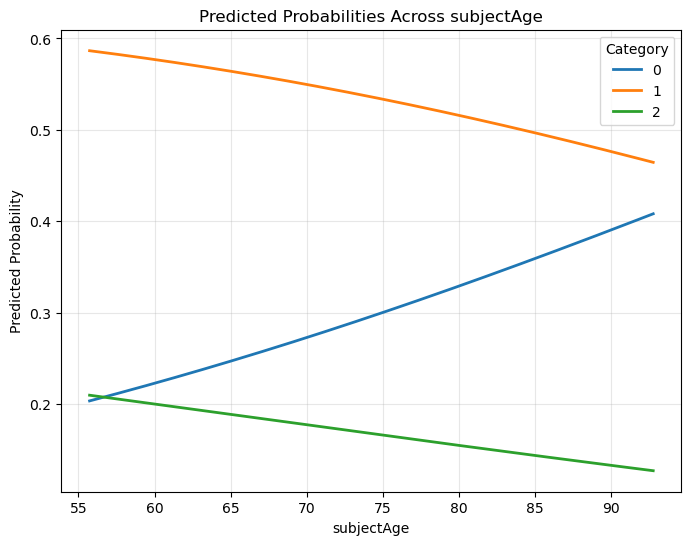

In [62]:
multinomial_logistic_regression(df=relevant_df_c, cat_col="researchGroup", con_col="subjectAge", reordering=['CN', 'MCI', 'AD'])

In [63]:
categorical_cols = ["APOE A1", "APOE A2", "CDGLOBAL", "subjectSex", "researchGroup"]
continuous_cols = ["subjectAge", "weightKg", "NPISCORE", "FAQTOTAL", "MMSCORE"]

train, val, test = create_dataset(tab_data=relevant_df_c,
                                  train_ratio=0.7,
                                  val_ratio=0.15,
                                  test_ratio=0.15)

train_df, val_df, test_df, cat_mapping = categorize(train_df=train,
                                                    val_df=val,
                                                    test_df=test,
                                                    categorical_columns=categorical_cols)

train_df, val_df, test_df, mean, std = normalize(train_df=train_df,
                                                val_df=val_df,
                                                test_df=test_df,
                                                continuous_columns=continuous_cols)

['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex']


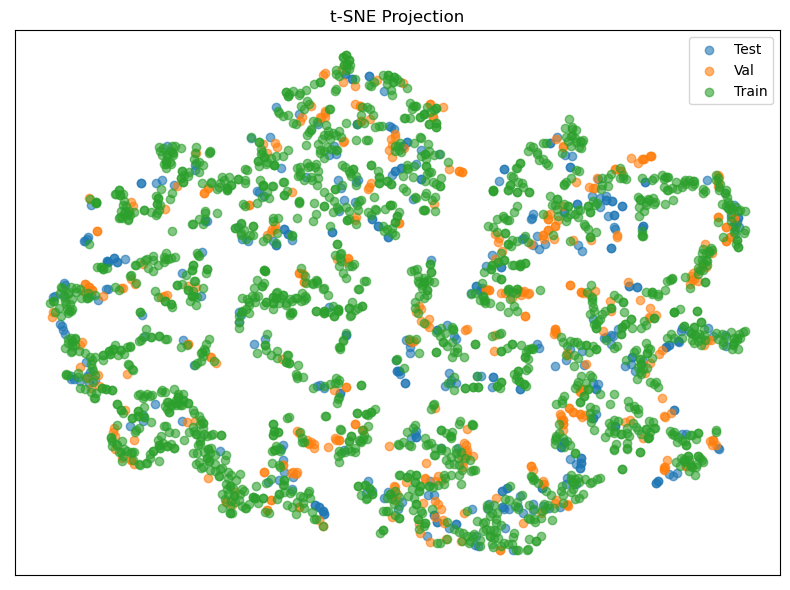

In [64]:
if "researchGroup" in categorical_cols:
    c_cols = categorical_cols.copy()
    c_cols.remove("researchGroup")

visualize_tsne(dfs=[train, val, test], labels=["Train", "Val", "Test"], continuous_columns=continuous_cols, categorical_columns=c_cols, sample_frac=1.0)

In [65]:
train_df = reorder_df(df=train_df, new_order=categorical_cols[:-1]+continuous_cols)
val_df = reorder_df(df=val_df, new_order=categorical_cols[:-1]+continuous_cols)
test_df = reorder_df(df=test_df, new_order=categorical_cols[:-1]+continuous_cols)
display(train_df)
display(val_df)
display(test_df)

,APOE A1,APOE A2,CDGLOBAL,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,MMSCORE,Field Strength,researchGroup,TE,im_path,Manufacturer,Slice Thickness,TR,TI,subjectIdentifier,dataIdentifier
0,0,0,0,0,-1.284255,-1.225395,-0.416382,-0.826103,0.230433,3.0,0,3.2544,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,Philips Medical Systems,1.2,6.8482,0.0,130_S_0449,130_S_0449_11625
1,0,0,0,0,-1.140944,-0.941817,0.226642,0.553134,0.711076,3.0,0,3.2544,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,Philips Medical Systems,1.2,6.8482,0.0,130_S_0449,130_S_0449_17355
2,1,1,1,0,0.034213,-0.752766,-0.737894,-0.826103,0.711076,3.0,1,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.0000,900.0,116_S_0382,116_S_0382_9326
3,1,1,1,0,0.177525,-0.752766,-0.094870,-0.826103,0.711076,3.0,1,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.0000,900.0,116_S_0382,116_S_0382_16134
4,1,1,1,0,0.328219,-0.960583,-0.416382,-0.826103,0.951398,3.0,1,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.0000,900.0,023_S_1190,023_S_1190_19390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1842,1,0,1,1,-0.484168,0.098661,-0.737894,-0.826103,0.711076,3.0,1,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.0000,900.0,023_S_0058,023_S_0058_19021
1843,1,1,1,0,-0.324476,0.061129,-0.737894,-0.826103,0.951398,3.0,1,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.0000,900.0,023_S_0926,023_S_0926_23726
1844,1,1,0,0,-0.170105,0.035412,-0.737894,-0.826103,0.951398,3.0,1,2.9100,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.0000,900.0,032_S_1169,032_S_1169_24831
1845,0,0,0,0,-1.308407,-0.884824,0.226642,-0.199177,-0.730854,3.0,0,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.0000,900.0,023_S_0331,023_S_0331_20973


,APOE A1,APOE A2,CDGLOBAL,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,MMSCORE,Field Strength,researchGroup,TE,im_path,Manufacturer,Slice Thickness,TR,TI,subjectIdentifier,dataIdentifier
0,2,1,1,0,-0.288846,0.603262,-0.737894,-0.826103,0.951398,3.0,1,2.848,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,GE MEDICAL SYSTEMS,1.2,6.628,900.0,007_S_1222,007_S_1222_14750
1,2,1,1,0,-0.140214,0.647050,-0.737894,-0.826103,0.711076,3.0,1,2.840,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,GE MEDICAL SYSTEMS,1.2,6.608,900.0,007_S_1222,007_S_1222_19930
2,1,0,1,0,-0.534115,-1.414446,-0.737894,-0.826103,0.951398,3.0,1,2.940,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.000,900.0,116_S_1249,116_S_1249_19660
3,1,0,1,0,-0.683166,-1.477695,-0.737894,-0.826103,0.951398,3.0,1,2.940,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.000,900.0,116_S_1249,116_S_1249_14572
4,1,1,0,1,1.665519,-0.052858,0.869666,-0.324562,-0.009889,3.0,0,2.940,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.000,900.0,023_S_0604,023_S_0604_9223
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,1,1,2,1,1.976712,0.092406,-0.094870,1.305445,-0.490532,3.0,0,2.940,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.000,900.0,023_S_0604,023_S_0604_22103
388,1,0,0,1,-0.378115,-2.912263,2.155714,-0.199177,0.470755,3.0,0,2.910,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.000,900.0,031_S_0830,031_S_0830_23269
389,1,1,1,0,0.673383,-0.683261,-0.737894,-0.826103,0.711076,3.0,1,2.940,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.000,900.0,023_S_0031,023_S_0031_18920
390,1,0,0,1,-0.081255,0.804824,-0.737894,0.929289,-0.971175,3.0,0,2.910,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.000,900.0,027_S_0835,027_S_0835_23202


,APOE A1,APOE A2,CDGLOBAL,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,MMSCORE,Field Strength,researchGroup,TE,im_path,Manufacturer,Slice Thickness,TR,TI,subjectIdentifier,dataIdentifier
0,1,1,0,1,0.093188,1.763288,-0.737894,0.302364,-2.172784,3.0,0,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.0000,900.0,023_S_0625,023_S_0625_9674
1,1,1,2,1,0.249592,1.523498,-0.094870,1.180060,-0.971175,3.0,0,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.0000,900.0,023_S_0625,023_S_0625_17205
2,1,0,2,1,0.306504,-0.059113,0.869666,1.681600,-2.413105,3.0,2,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.0000,900.0,116_S_0487,116_S_0487_16290
3,1,0,0,1,0.161563,0.209173,-0.094870,0.929289,-1.692140,3.0,2,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.0000,900.0,116_S_0487,116_S_0487_9335
4,1,1,1,1,0.290946,0.035412,-0.737894,-0.826103,0.230433,3.0,1,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Annua...,SIEMENS,1.2,2300.0000,900.0,027_S_0403,027_S_0403_15891
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
374,1,1,1,1,0.424841,0.508736,-0.737894,-0.826103,0.470755,3.0,1,3.1329,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,Philips Medical Systems,1.2,6.7657,0.0,018_S_0369,018_S_0369_21666
375,1,1,1,0,0.569797,0.524027,-0.737894,-0.826103,0.470755,3.0,1,2.9400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,SIEMENS,1.2,2300.0000,900.0,023_S_0061,023_S_0061_19169
376,2,1,1,0,0.809745,-0.090390,-0.737894,-0.826103,0.711076,3.0,1,2.8400,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,GE MEDICAL SYSTEMS,1.2,6.6160,900.0,127_S_0260,127_S_0260_21268
377,1,1,2,1,0.043629,1.170417,-0.737894,2.308526,-5.056644,3.0,0,3.1600,/data/local/kgutjahr/datasets/ADNI/ADNI1_Compl...,Philips Medical Systems,1.2,6.8054,0.0,002_S_1070,002_S_1070_24068


In [66]:
train_df, val_df, test_df = cut_datasets(train_df=train_df, val_df=val_df, test_df=test_df, sizes=[1460, 375, 375])

In [67]:
train_df.columns

Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE', 'Field Strength',
       'researchGroup', 'TE', 'im_path', 'Manufacturer', 'Slice Thickness',
       'TR', 'TI', 'subjectIdentifier', 'dataIdentifier'],
      dtype='object')

In [68]:
display([i for i in test_df["subjectIdentifier"].unique() if i in train_df["subjectIdentifier"].unique()])
display([i for i in val_df["subjectIdentifier"].unique() if i in train_df["subjectIdentifier"].unique()])
display([i for i in test_df["subjectIdentifier"].unique() if i in val_df["subjectIdentifier"].unique()])

[]

[]

[]

In [69]:
display(get_counts(df=train_df, feature="researchGroup"))
display(get_counts(df=val_df, feature="researchGroup"))
display(get_counts(df=test_df, feature="researchGroup"))

,Count,Percentage
0,769,52.671
1,451,30.890
2,240,16.438


,Count,Percentage
0,202,53.867
1,113,30.133
2,60,16.000


,Count,Percentage
0,185,49.333
1,128,34.133
2,62,16.533


In [70]:
display(get_counts(df=train_df, feature="researchGroup"))
display(get_counts(df=val_df, feature="researchGroup"))
display(get_counts(df=test_df, feature="researchGroup"))

,Count,Percentage
0,769,52.671
1,451,30.890
2,240,16.438


,Count,Percentage
0,202,53.867
1,113,30.133
2,60,16.000


,Count,Percentage
0,185,49.333
1,128,34.133
2,62,16.533


In [71]:
lengths = get_lengths(df_list=[train_df, val_df, test_df], continuous_columns=continuous_cols, categorical_columns=categorical_cols[:-1])
lengths

{'APOE A1': 3,
 'APOE A2': 3,
 'CDGLOBAL': 6,
 'subjectSex': 2,
 'subjectAge': 1,
 'weightKg': 1,
 'NPISCORE': 1,
 'FAQTOTAL': 1,
 'MMSCORE': 1}

In [72]:
normal_path = os.path.join(PROCESSED_PATH, "final_normal")
normal_path

'/data/local/kgutjahr/datasets/ADNI/dataset_files/final_normal'

In [73]:
display(train_df.shape)
display(val_df.shape)
display(test_df.shape)

(1460, 19)

(375, 19)

(375, 19)

In [74]:
save_lengths(lengths=lengths, file_name="tabular_lengths.pt", save_directory=normal_path)
save_dataset(df=train_df, save_directory=normal_path, split="train", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=PROCESSED_PATH)
save_dataset(df=val_df, save_directory=normal_path, split="val", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=PROCESSED_PATH)
save_dataset(df=test_df, save_directory=normal_path, split="test", keep_cols=categorical_cols[:-1]+continuous_cols, image_dir=PROCESSED_PATH)

Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')


In [75]:
plot_histogram_comparison(train_df=train_df, val_df=val_df, test_df=test_df, feature="weightKg")

TypeError: plot_histogram_comparison() missing 1 required positional argument: 'feature_name'

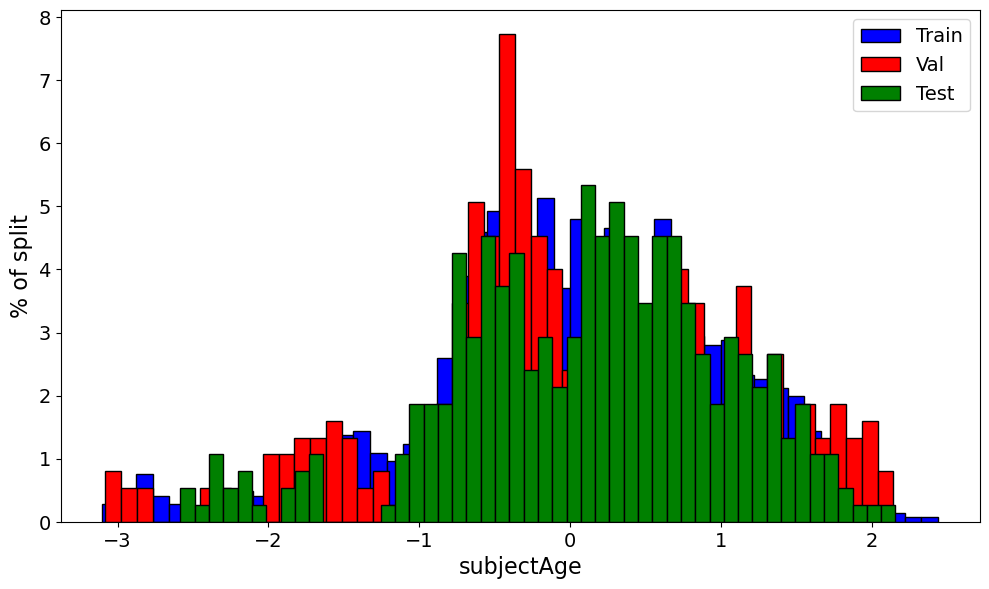

In [ ]:
plot_histogram_comparison(train_df=train_df, val_df=val_df, test_df=test_df, feature="subjectAge")

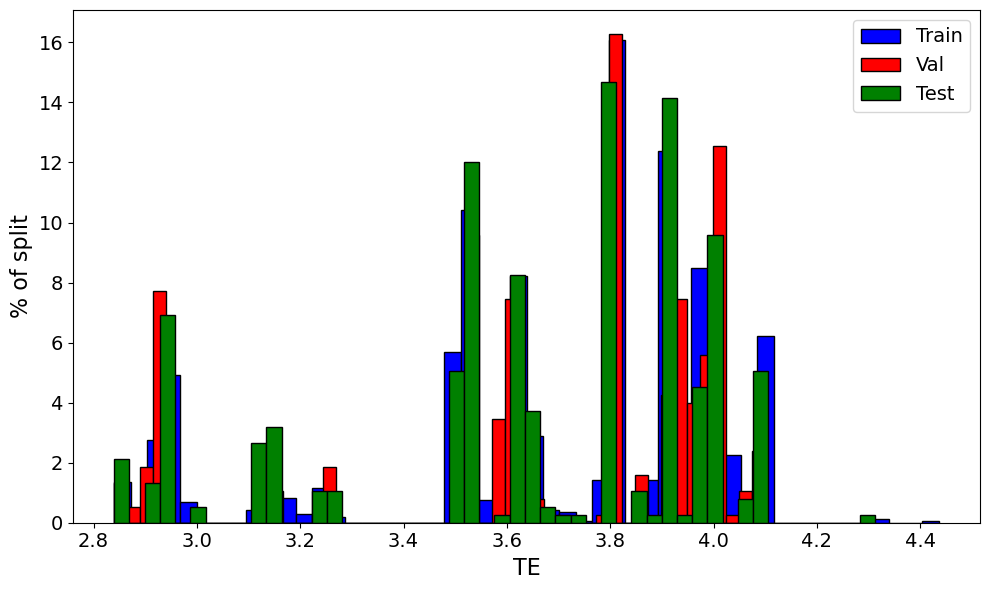

In [ ]:
plot_histogram_comparison(train_df=train_df, val_df=val_df, test_df=test_df, feature="TE")

In [76]:
def categorize_single_df(df: pd.DataFrame, categorical_columns: list[str]) -> Tuple[pd.DataFrame, Dict[str, dict]]:
    # Deep copies to ensure no slice/view issues
    df_copy = df.copy(deep=True)
    
    category_mappings = {}

    for col in categorical_columns:
        # Combine all categories
        all_categories = pd.Index(
            pd.concat([
                df_copy[col],
            ]).dropna().unique()
        )
        
        # Store the mapping
        mapping = {category: code for code, category in enumerate(all_categories)}
        category_mappings[col] = mapping

        # Assign categories
        df_copy[col] = pd.Categorical(df_copy[col], categories=all_categories)
        df_copy[col] = df_copy[col].cat.codes

    return df_copy, category_mappings

In [77]:
relevant_df_cat, relevant_map = categorize_single_df(df=relevant_df_c, categorical_columns=categorical_cols)

display(relevant_df_cat.corr(method="kendall"))

#plot_scatter(df=relevant_df_cat, feature="subjectAge", label="researchGroup", mapping=relevant_map)
#plot_scatter(df=train_df, feature="subjectAge", label="researchGroup", mapping=relevant_map)
#plot_scatter(df=val_df, feature="subjectAge", label="researchGroup", mapping=relevant_map)
#plot_scatter(df=test_df, feature="subjectAge", label="researchGroup", mapping=relevant_map)

/tmp/ipykernel_1723963/2984051344.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  display(relevant_df_cat.corr(method="kendall"))


,researchGroup,subjectSex,subjectAge,weightKg,NPISCORE,FAQTOTAL,MMSCORE,CDGLOBAL,APOE A1,APOE A2,Slice Thickness,Field Strength,TE,TR,TI
researchGroup,1.000000,-0.161615,0.003389,-0.081166,-0.032768,-0.030276,0.020489,0.531168,0.005662,0.036130,NaN,-0.006045,0.010268,-0.029486,-0.048323
subjectSex,-0.161615,1.000000,0.067938,0.440807,0.089332,0.028391,-0.014057,-0.097285,-0.029809,-0.039665,NaN,-0.019673,0.078984,-0.041491,-0.039532
subjectAge,0.003389,0.067938,1.000000,-0.068062,-0.016930,-0.006261,-0.002569,0.034681,0.145846,0.110520,NaN,-0.013365,-0.017369,0.025998,0.034794
weightKg,-0.081166,0.440807,-0.068062,1.000000,0.002390,-0.046247,0.057816,-0.036487,-0.008599,0.062086,NaN,0.010420,0.046755,-0.052687,-0.030317
NPISCORE,-0.032768,0.089332,-0.016930,0.002390,1.000000,0.467810,-0.326245,0.044163,-0.128034,-0.153472,NaN,0.034679,0.025947,-0.058092,0.001249
FAQTOTAL,-0.030276,0.028391,-0.006261,-0.046247,0.467810,1.000000,-0.578843,0.089343,-0.187399,-0.240442,NaN,0.016597,0.018305,0.007283,0.005622
MMSCORE,0.020489,-0.014057,-0.002569,0.057816,-0.326245,-0.578843,1.000000,-0.079022,0.175689,0.215200,NaN,-0.005815,-0.000866,-0.031466,0.005817
CDGLOBAL,0.531168,-0.097285,0.034681,-0.036487,0.044163,0.089343,-0.079022,1.000000,0.024630,0.027418,NaN,0.011334,0.000308,-0.005823,-0.000450
APOE A1,0.005662,-0.029809,0.145846,-0.008599,-0.128034,-0.187399,0.175689,0.024630,1.000000,0.349994,NaN,-0.047344,0.026759,-0.037833,-0.004931
APOE A2,0.036130,-0.039665,0.110520,0.062086,-0.153472,-0.240442,0.215200,0.027418,0.349994,1.000000,NaN,0.018246,-0.044691,0.012947,-0.052197


## Shifts: Weight

In [78]:
w_train, w_val, w_test = create_shifted_splits(df=relevant_df_c, split=[{"weightKg": (">=", 60)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols, cat_columns=categorical_cols, mode=1)

2228
390
Shape of train df:	(1722, 19)
Shape of val df:	(393, 19)
Shape of test df:	(381, 19)
Total Size: 2496
Ratio -> Train: 0.69 | Val: 0.16 | Test: 0.15


In [79]:
w_train, w_val, w_test = cut_datasets(train_df=w_train, val_df=w_val, test_df=w_test, sizes=[1460, 375, 375])

In [80]:
display([i for i in w_test["subjectIdentifier"].unique() if i in w_train["subjectIdentifier"].unique()])
display([i for i in w_val["subjectIdentifier"].unique() if i in w_train["subjectIdentifier"].unique()])
display([i for i in w_test["subjectIdentifier"].unique() if i in w_val["subjectIdentifier"].unique()])

[]

[]

[]

In [81]:
display(w_train.shape)
display(w_val.shape)
display(w_test.shape)

(1460, 19)

(375, 19)

(375, 19)

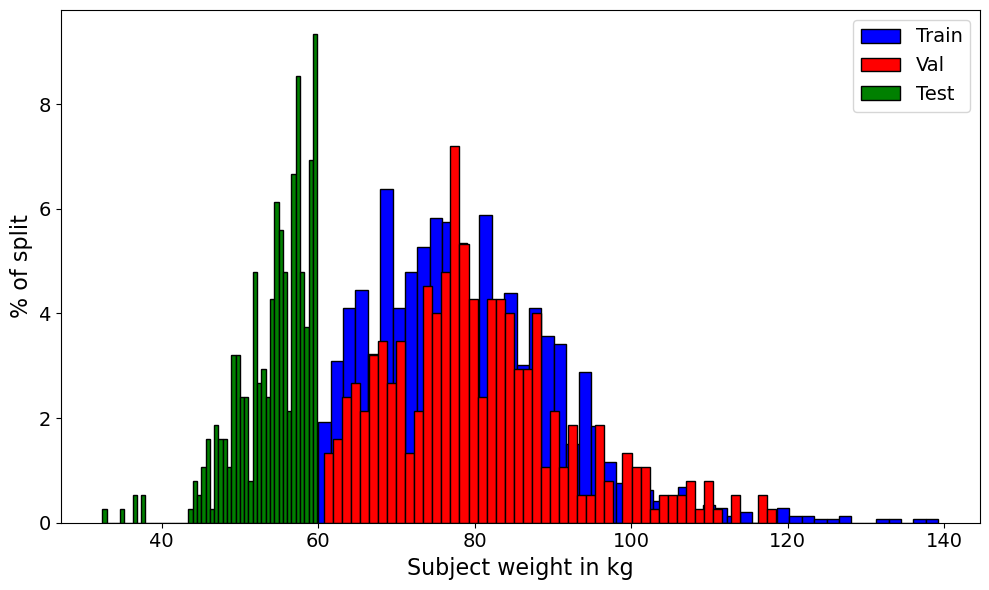

In [102]:
plot_histogram_comparison(train_df=w_train, val_df=w_val, test_df=w_test, feature="weightKg", feature_name="Subject weight in kg")

In [83]:
w_train_df, w_val_df, w_test_df, cat_mapping = categorize(train_df=w_train,
                                                    val_df=w_val,
                                                    test_df=w_test,
                                                    categorical_columns=categorical_cols)

CONTINUUOUS COls: ['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
CATEGORICAL COls: ['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']


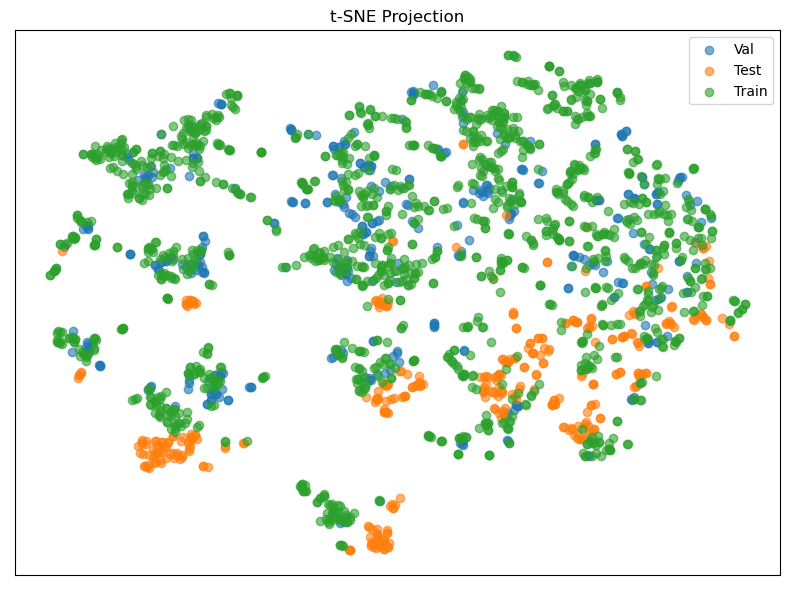

Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')


In [84]:
weight_dir = os.path.join(PROCESSED_PATH, "final_weight")
save_new_datasets(train=w_train, val=w_val, test=w_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=weight_dir, image_directory=PROCESSED_PATH)

## Shifts: Age

In [85]:
display(relevant_df_c["subjectAge"].quantile(0.15))
display(relevant_df_c["subjectAge"].quantile(0.85))

70.5753

83.72325999999998

In [86]:
age_train, age_val, age_test = create_shifted_splits(df=relevant_df_c, split=[{"subjectAge": (">=", 68)}, {"subjectAge": ("<=", 87)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols, cat_columns=categorical_cols, mode=1)

2208
410
Shape of train df:	(1725, 19)
Shape of val df:	(398, 19)
Shape of test df:	(380, 19)
Total Size: 2503
Ratio -> Train: 0.69 | Val: 0.16 | Test: 0.15


In [87]:
age_train, age_val, age_test = cut_datasets(train_df=age_train, val_df=age_val, test_df=age_test, sizes=[1460, 375, 375])

In [88]:
display([i for i in age_train["subjectIdentifier"].unique() if i in age_val["subjectIdentifier"].unique()])
display([i for i in age_train["subjectIdentifier"].unique() if i in age_test["subjectIdentifier"].unique()])
display([i for i in age_test["subjectIdentifier"].unique() if i in age_val["subjectIdentifier"].unique()])

[]

[]

[]

In [89]:
display(get_counts(df=age_train, feature="researchGroup"))
display(get_counts(df=age_val, feature="researchGroup"))
display(get_counts(df=age_test, feature="researchGroup"))

,Count,Percentage
MCI,721,49.384
CN,512,35.068
AD,227,15.548


,Count,Percentage
MCI,180,48.0
CN,138,36.8
AD,57,15.2


,Count,Percentage
MCI,248,66.133
AD,79,21.067
CN,48,12.8


In [90]:
display(age_train.shape)
display(age_val.shape)
display(age_test.shape)

(1460, 19)

(375, 19)

(375, 19)

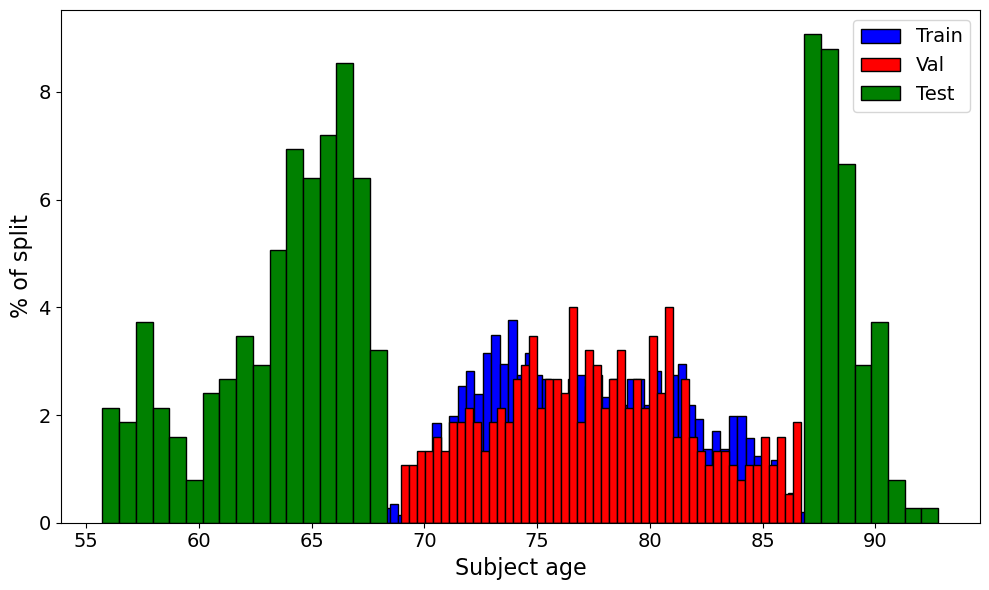

In [92]:
plot_histogram_comparison(train_df=age_train, val_df=age_val, test_df=age_test, feature="subjectAge", feature_name="Subject age")

CONTINUUOUS COls: ['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
CATEGORICAL COls: ['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']


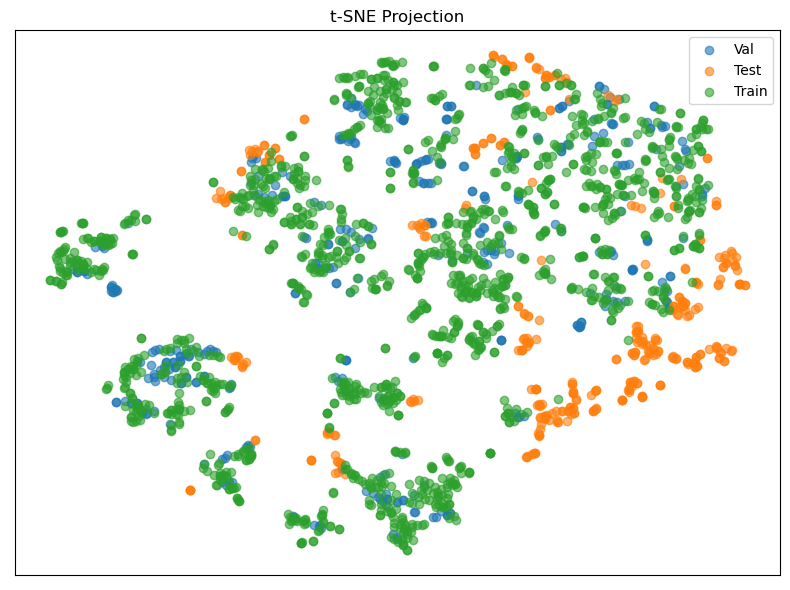

Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')


In [93]:
age_dir = os.path.join(PROCESSED_PATH, "final_age")
save_new_datasets(train=age_train, val=age_val, test=age_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=age_dir, image_directory=PROCESSED_PATH)

## Split: TE

In [94]:
split_col = "TE"
display(relevant_df_c[split_col].max())
display(relevant_df_c[split_col].min())
display(relevant_df_c[split_col].quantile(0.15))
display(relevant_df_c[split_col].quantile(0.85))

4.436

2.84

3.2544

3.9992

In [95]:
te_train, te_val, te_test = create_shifted_splits(df=relevant_df_c, split=[{"TE": (">=", 3.2544)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols+["TE"], cat_columns=categorical_cols, mode=1)

2240
378
Shape of train df:	(1461, 19)
Shape of val df:	(385, 19)
Shape of test df:	(378, 19)
Total Size: 2224
Ratio -> Train: 0.66 | Val: 0.17 | Test: 0.17


In [96]:
te_train, te_val, te_test = cut_datasets(train_df=te_train, val_df=te_val, test_df=te_test, sizes=[1460, 375, 375])

In [97]:
display([i for i in te_train["subjectIdentifier"].unique() if i in te_val["subjectIdentifier"].unique()])
display([i for i in te_train["subjectIdentifier"].unique() if i in te_test["subjectIdentifier"].unique()])
display([i for i in te_test["subjectIdentifier"].unique() if i in te_val["subjectIdentifier"].unique()])

[]

[]

[]

In [98]:
display(get_counts(df=te_train, feature="researchGroup"))
display(get_counts(df=te_val, feature="researchGroup"))
display(get_counts(df=te_test, feature="researchGroup"))

,Count,Percentage
MCI,793,54.315
CN,430,29.452
AD,237,16.233


,Count,Percentage
MCI,196,52.267
CN,112,29.867
AD,67,17.867


,Count,Percentage
MCI,190,50.667
CN,125,33.333
AD,60,16.0


In [99]:
display(te_train.shape)
display(te_val.shape)
display(te_test.shape)

(1460, 19)

(375, 19)

(375, 19)

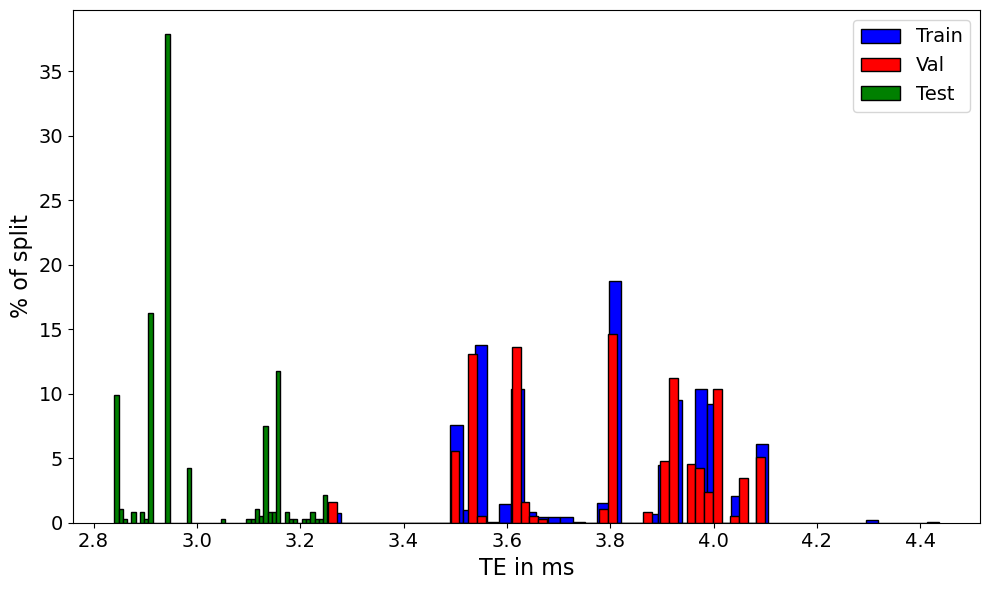

In [101]:
plot_histogram_comparison(train_df=te_train, val_df=te_val, test_df=te_test, feature=split_col, feature_name="TE in ms")

CONTINUUOUS COls: ['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
CATEGORICAL COls: ['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']


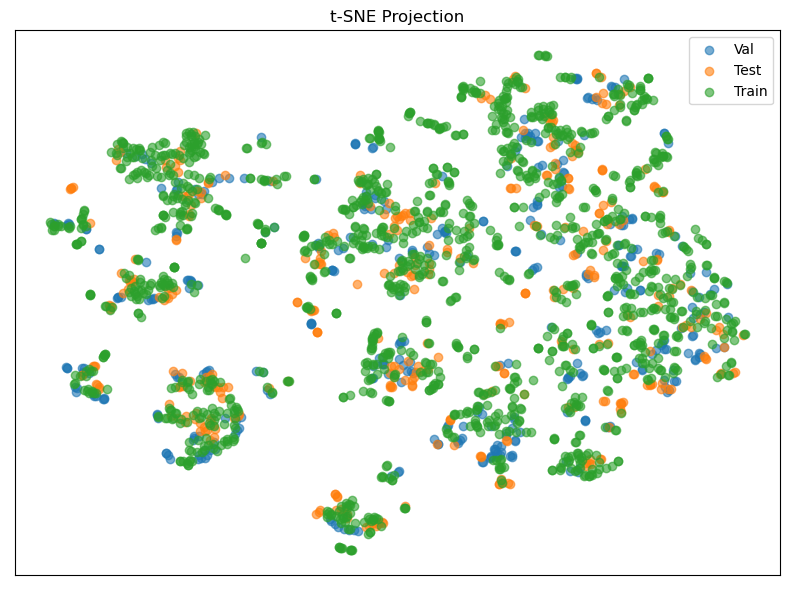

Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')


In [ ]:
te_dir = os.path.join(PROCESSED_PATH, "final_TE")
save_new_datasets(train=te_train, val=te_val, test=te_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=te_dir, image_directory=PROCESSED_PATH)

In [ ]:
from scipy.spatial.distance import jensenshannon

def align_dataframes(*dfs):
    all_indices = pd.Index([])
    for df in dfs:
        all_indices = all_indices.union(df.index)
    
    # Reindex each DataFrame and fill missing values with 0
    aligned_dfs = [df.reindex(all_indices, fill_value=0) for df in dfs]
    
    return aligned_dfs

def kl_divergence(p_df, q_df):
    """Compute D_KL(P || Q) between two DataFrames with a 'Percentage' column."""
    p_df, q_df = align_dataframes(p_df, q_df)
    
    p = p_df["Percentage"].to_numpy(dtype=float)
    q = q_df["Percentage"].to_numpy(dtype=float)

    # Convert percentages to probabilities
    p = p / p.sum()
    q = q / q.sum()

    return float(jensenshannon(p, q))

In [ ]:
display(get_counts(df=train, feature="researchGroup").sort_index())
display(get_counts(df=w_train, feature="researchGroup").sort_index())
display(get_counts(df=age_train, feature="researchGroup").sort_index())
display(get_counts(df=te_train, feature="researchGroup").sort_index())

,Count,Percentage
AD,302,16.351
CN,566,30.644
MCI,979,53.005


,Count,Percentage
AD,246,16.849
CN,460,31.507
MCI,754,51.644


,Count,Percentage
AD,227,15.548
CN,512,35.068
MCI,721,49.384


,Count,Percentage
AD,237,16.233
CN,430,29.452
MCI,793,54.315


In [ ]:
print(kl_divergence(p_df=get_counts(df=train, feature="CDGLOBAL").sort_index(), q_df=get_counts(df=test, feature="CDGLOBAL").sort_index()))
print(kl_divergence(p_df=get_counts(df=w_train, feature="CDGLOBAL").sort_index(), q_df=get_counts(df=w_test, feature="CDGLOBAL").sort_index()))
print(kl_divergence(p_df=get_counts(df=age_train, feature="CDGLOBAL").sort_index(), q_df=get_counts(df=age_test, feature="CDGLOBAL").sort_index()))
print(kl_divergence(p_df=get_counts(df=te_train, feature="CDGLOBAL").sort_index(), q_df=get_counts(df=te_test, feature="CDGLOBAL").sort_index()))

0.047932526696989206
0.053916935318804884
0.1430034135554012
0.06142625347234505


## Try New Shifts

#### Weight reversed

In [ ]:
w_train, w_val, w_test = create_shifted_splits(df=relevant_df_c, split=[{"weightKg": ("<=", 89)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols, cat_columns=categorical_cols, mode=1)

2204
414
Shape of train df:	(1699, 19)
Shape of val df:	(426, 19)
Shape of test df:	(384, 19)
Total Size: 2509
Ratio -> Train: 0.68 | Val: 0.17 | Test: 0.15


In [ ]:
w_train, w_val, w_test = cut_datasets(train_df=w_train, val_df=w_val, test_df=w_test, sizes=[1460, 375, 375])

In [ ]:
display([i for i in w_test["subjectIdentifier"].unique() if i in w_train["subjectIdentifier"].unique()])
display([i for i in w_val["subjectIdentifier"].unique() if i in w_train["subjectIdentifier"].unique()])
display([i for i in w_test["subjectIdentifier"].unique() if i in w_val["subjectIdentifier"].unique()])

[]

[]

[]

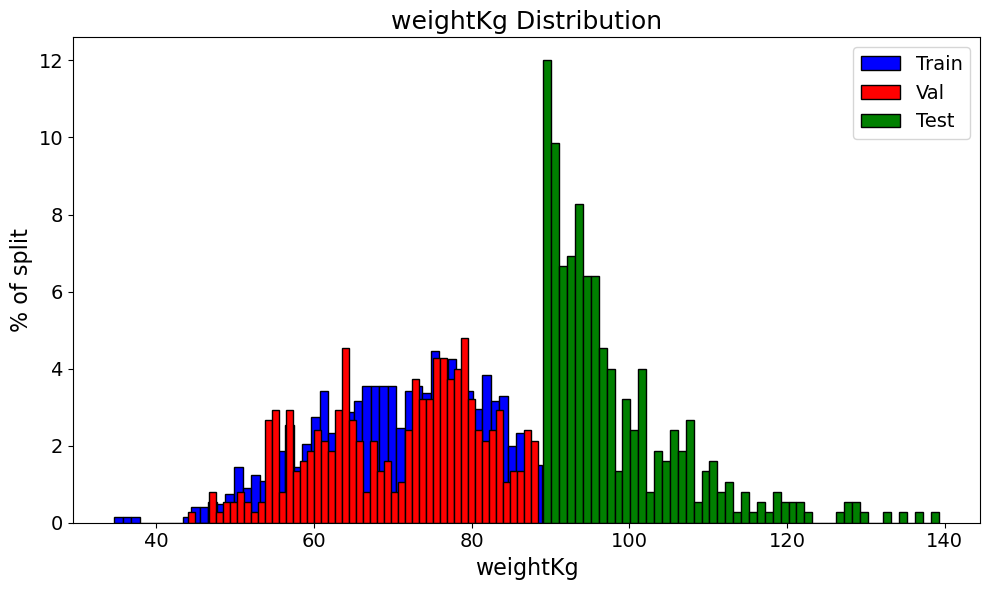

In [ ]:
plot_histogram_comparison(train_df=w_train, val_df=w_val, test_df=w_test, feature="weightKg")

CONTINUUOUS COls: ['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
CATEGORICAL COls: ['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']


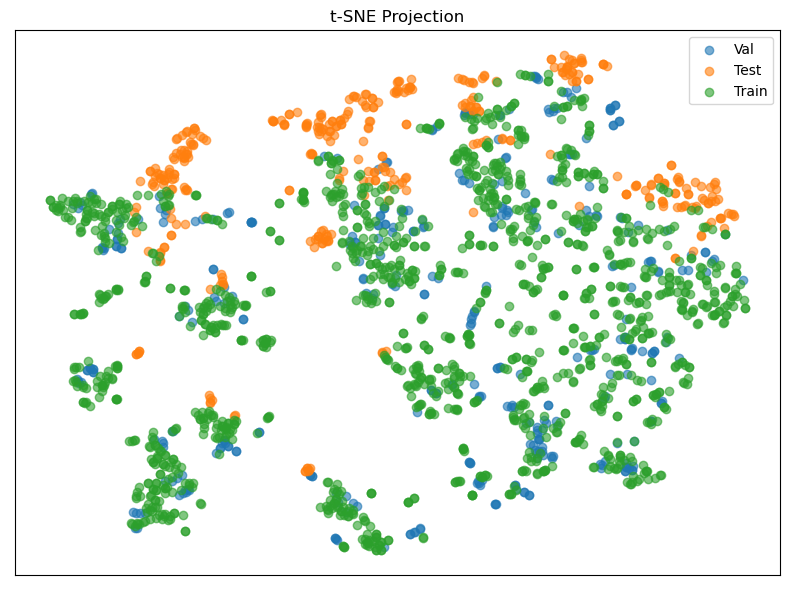

Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')


In [ ]:
weight_dir = os.path.join(PROCESSED_PATH, "final_weight_reversed")
save_new_datasets(train=w_train, val=w_val, test=w_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=weight_dir, image_directory=PROCESSED_PATH)

## Age > 70

In [ ]:
age_train, age_val, age_test = create_shifted_splits(df=relevant_df_c, split=[{"subjectAge": (">", 71)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols, cat_columns=categorical_cols, mode=1)

2191
427
Shape of train df:	(1742, 19)
Shape of val df:	(392, 19)
Shape of test df:	(384, 19)
Total Size: 2518
Ratio -> Train: 0.69 | Val: 0.16 | Test: 0.15


In [ ]:
age_train, age_val, age_test = cut_datasets(train_df=age_train, val_df=age_val, test_df=age_test, sizes=[1460, 375, 375])

In [ ]:
display([i for i in age_train["subjectIdentifier"].unique() if i in age_val["subjectIdentifier"].unique()])
display([i for i in age_train["subjectIdentifier"].unique() if i in age_test["subjectIdentifier"].unique()])
display([i for i in age_test["subjectIdentifier"].unique() if i in age_val["subjectIdentifier"].unique()])

[]

[]

[]

In [ ]:
display(get_counts(df=age_train, feature="researchGroup"))
display(get_counts(df=age_val, feature="researchGroup"))
display(get_counts(df=age_test, feature="researchGroup"))

,Count,Percentage
MCI,729,49.932
CN,521,35.685
AD,210,14.384


,Count,Percentage
MCI,175,46.667
CN,138,36.8
AD,62,16.533


,Count,Percentage
MCI,261,69.6
AD,88,23.467
CN,26,6.933


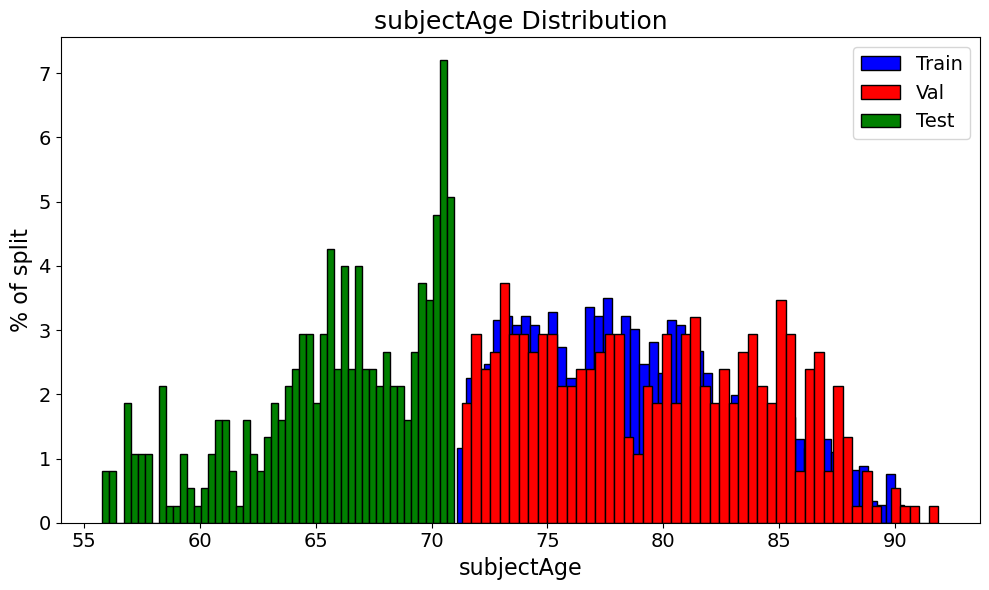

In [ ]:
plot_histogram_comparison(train_df=age_train, val_df=age_val, test_df=age_test, feature="subjectAge")

CONTINUUOUS COls: ['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
CATEGORICAL COls: ['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']


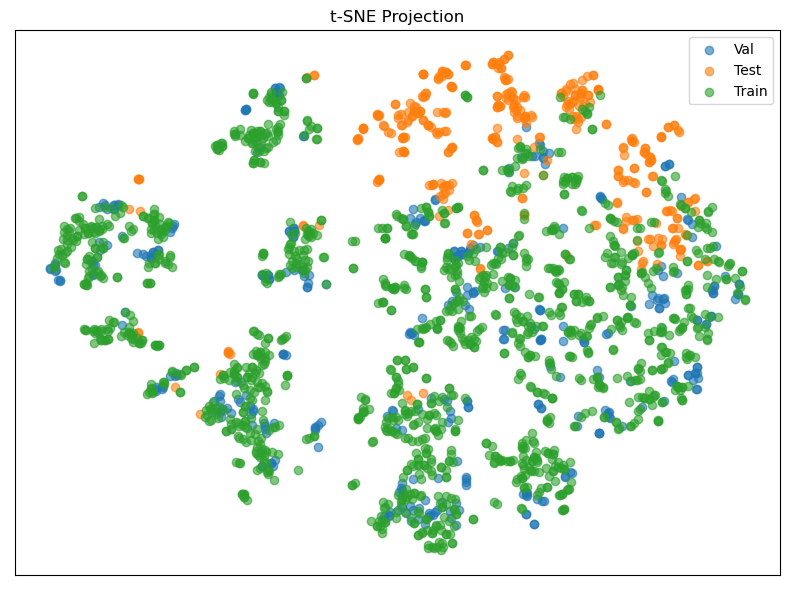

Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')


In [ ]:
age_dir = os.path.join(PROCESSED_PATH, "final_age_reversed")
save_new_datasets(train=age_train, val=age_val, test=age_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=age_dir, image_directory=PROCESSED_PATH)

## TE (> 3.2544)

In [ ]:
te_train, te_val, te_test = create_shifted_splits(df=relevant_df_c, split=[{"TE": ("<", 4.0)}], split_cond="and", ratio=[1850, 390, 380], con_columns=continuous_cols+["TE"], cat_columns=categorical_cols, mode=1)

2227
391
Shape of train df:	(1621, 19)
Shape of val df:	(402, 19)
Shape of test df:	(379, 19)
Total Size: 2402
Ratio -> Train: 0.67 | Val: 0.17 | Test: 0.16


In [ ]:
te_train, te_val, te_test = cut_datasets(train_df=te_train, val_df=te_val, test_df=te_test, sizes=[1460, 375, 375])

In [ ]:
display([i for i in te_train["subjectIdentifier"].unique() if i in te_val["subjectIdentifier"].unique()])
display([i for i in te_train["subjectIdentifier"].unique() if i in te_test["subjectIdentifier"].unique()])
display([i for i in te_test["subjectIdentifier"].unique() if i in te_val["subjectIdentifier"].unique()])

[]

[]

[]

In [ ]:
display(get_counts(df=te_train, feature="researchGroup"))
display(get_counts(df=te_val, feature="researchGroup"))
display(get_counts(df=te_test, feature="researchGroup"))

,Count,Percentage
MCI,775,53.082
CN,440,30.137
AD,245,16.781


,Count,Percentage
MCI,198,52.8
CN,114,30.4
AD,63,16.8


,Count,Percentage
MCI,190,50.667
CN,122,32.533
AD,63,16.8


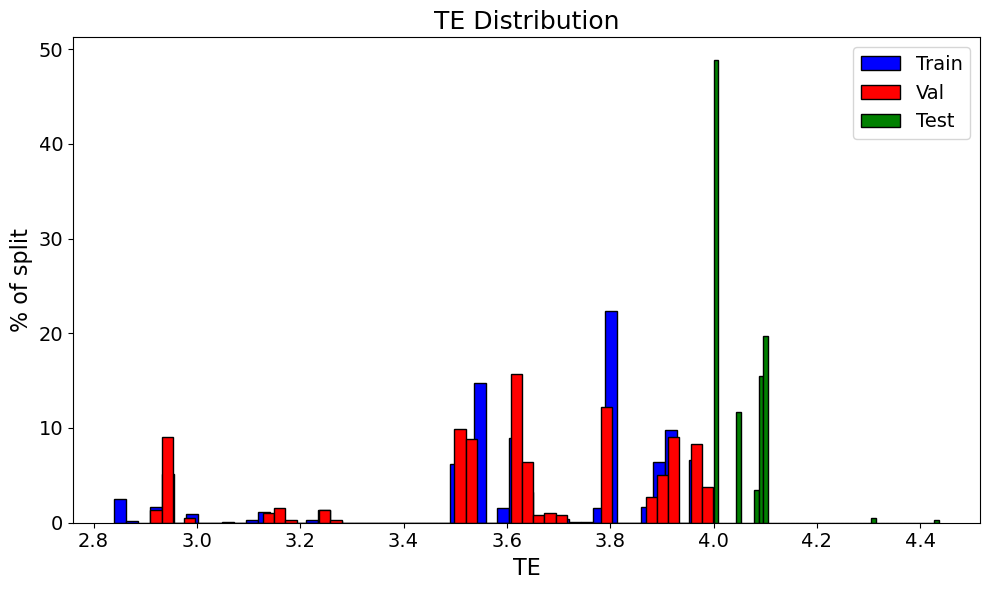

In [ ]:
plot_histogram_comparison(train_df=te_train, val_df=te_val, test_df=te_test, feature=split_col)

CONTINUUOUS COls: ['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
CATEGORICAL COls: ['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['subjectAge', 'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE']
['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'researchGroup']


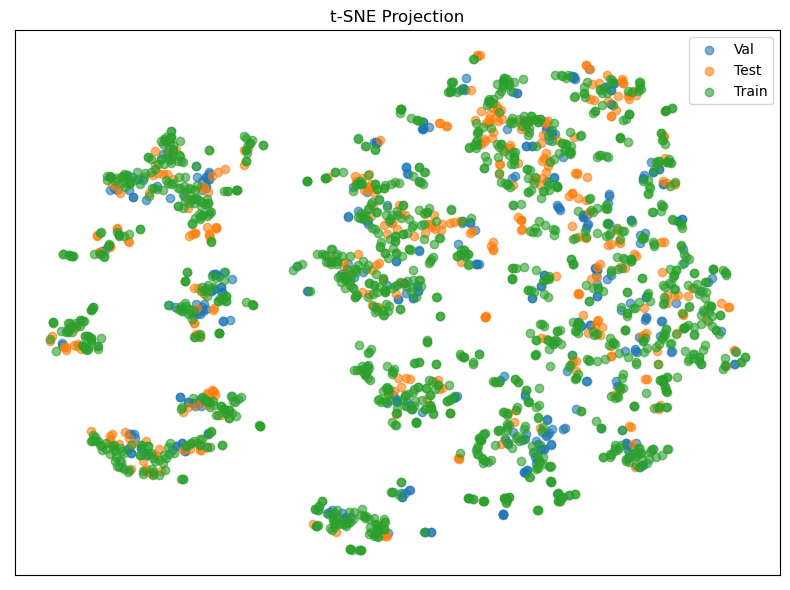

Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')
Index(['APOE A1', 'APOE A2', 'CDGLOBAL', 'subjectSex', 'subjectAge',
       'weightKg', 'NPISCORE', 'FAQTOTAL', 'MMSCORE'],
      dtype='object')


In [ ]:
te_dir = os.path.join(PROCESSED_PATH, "final_TE_reversed")
save_new_datasets(train=te_train, val=te_val, test=te_test, cat_cols=categorical_cols, con_cols=continuous_cols, save_directory=te_dir, image_directory=PROCESSED_PATH)